In [355]:
import os
import pandas as pd
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from networkx.algorithms.community import modularity
from community import community_louvain
import numpy as np

In [356]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usernames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [357]:
def assign_strength(df, inflection_point, party_flag):
    """ Assigns 'strong' or 'weak' based on the affiliation score. """
    if party_flag == 'R':
        return 'strong' if df['affiliation_score'] >= inflection_point else 'weak'
    else:  # 'D'
        return 'strong' if df['affiliation_score'] <= inflection_point else 'weak'

In [358]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [359]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_congress_member_to_affiliation_score.pth',weights_only=False))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)
    df_data['strength'] = df_data.apply(lambda x: assign_strength(x, 0.75 if x['party'] == 'R' else -0.75, x['party']), axis=1)
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]
    
    return df_data, republican_df, democratic_df

In [360]:
def degree_lower_n_remover(df_data,G_bipartite,n):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= n}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [361]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [2032]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [2033]:
# NEW VERSION CHECK IF WORKS AND THEN TRY IMPLEMENT THE OTHERS

def louvain_two_communities(G):

    """ Run the Louvain algorithm to detect communities """

    partition = community_louvain.best_partition(G)


    initial_communities = {}
    for node, community in partition.items():
        if community not in initial_communities:
            initial_communities[community] = set()
        initial_communities[community].add(node)

    # Convert dictionary of communities into a list of sets
    communities_list = list(initial_communities.values())
    # print(len(communities_list))

    # Step 3: Merge communities into two based on edge connectivity
    if len(communities_list) > 2:
        # communities = merge_communities_by_edge_count(G, communities_list)
        communities = merge_n_communities_by_edge_count(G, communities_list, 2)
        # communities = merge_communities_max_modularity(G, communities_list)
        # communities = merge_into_two_communities(communities_list)
    else:
        communities = communities_list
    # Create the final two-community split
    node_to_community = {}
    for node in communities[0]:
        node_to_community[node] = 1
    for node in communities[1]:
        node_to_community[node] = 2

    # Calculate modularity value
    try:
        mod_value = modularity(G, communities)
    except:
        mod_value = 0

    return communities, mod_value

In [2034]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [2035]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politician
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [2215]:
""" THIS DOES DEGREE RATIO FOR NODES FOR DEGREES TO NODES IN COMMUNITY/ TOTAL DEGREES PER NODE """

### Wouldn't work so well for democrat, but should work for republican

def calculate_degree_ratio(node, graph, node_to_community):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0  # Avoid division by zero if no neighbors
    # sign = 1 if graph.nodes[node]['party'] == 'R' else -1
    in_community = sum(1 for neighbor in neighbors if node_to_community.get(neighbor) == node_to_community.get(node))
    out_community = len(neighbors) - in_community
    #return (in_community- (0.75*out_community))#/(in_community+out_community) if (in_community+out_community) != 0 else 0
    return len(neighbors)*((in_community)-(out_community))

def apply_degree_ratio(df_data, G, node_to_community):
    """ Applies the degree ratio to the dataframe """
    df_data['init_degree_ratio'] = df_data['current_twitter_name'].apply(lambda x: calculate_degree_ratio(x, G, node_to_community))

    df_data['degree_ratio'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_degree_ratio'], 
                                    -df_data['init_degree_ratio'])
    df_data.drop(columns=['init_degree_ratio'], inplace=True)
    for node in G.nodes():
        G.nodes[node]['degree_ratio'] = df_data[df_data['current_twitter_name'] == node]['degree_ratio'].values[0]
    return df_data, G




In [2216]:
""" THIS DOES DEGREE RATIO FOR NODES FOR DEGREES TO NODES IN COMMUNITY/ TOTAL DEGREES PER NODE """

### Wouldn't work so well for democrat, but should work for republican

def calculate_degree_ratio2(node, graph, node_to_community):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0  # Avoid division by zero if no neighbors
    # sign = 1 if graph.nodes[node]['party'] == 'R' else -1
    in_community = sum(1 for neighbor in neighbors if node_to_community.get(neighbor) == node_to_community.get(node))
    out_community = len(neighbors) - in_community
    #return (in_community- (0.75*out_community))#/(in_community+out_community) if (in_community+out_community) != 0 else 0
    return len(neighbors)*((in_community)+(out_community))

def apply_degree_ratio2(df_data, G, node_to_community):
    """ Applies the degree ratio to the dataframe """
    df_data['init_degree_ratio2'] = df_data['current_twitter_name'].apply(lambda x: calculate_degree_ratio2(x, G, node_to_community))

    df_data['degree_ratio2'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_degree_ratio2'], 
                                    -df_data['init_degree_ratio2'])
    df_data.drop(columns=['init_degree_ratio2'], inplace=True)
    for node in G.nodes():
        G.nodes[node]['degree_ratio2'] = df_data[df_data['current_twitter_name'] == node]['degree_ratio2'].values[0]
    return df_data, G




In [2217]:
""" THIS DOES DEGREE RATIO FOR NODES FOR DEGREES TO NODES IN COMMUNITY/ TOTAL DEGREES PER NODE """

### Wouldn't work so well for democrat, but should work for republican

def calculate_degree_ratio3(node, graph, node_to_community):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0  # Avoid division by zero if no neighbors
    # sign = 1 if graph.nodes[node]['party'] == 'R' else -1
    in_community = sum(1 for neighbor in neighbors if node_to_community.get(neighbor) == node_to_community.get(node))
    out_community = len(neighbors) - in_community
    #return (in_community- (0.75*out_community))#/(in_community+out_community) if (in_community+out_community) != 0 else 0
    return in_community/len(neighbors) if (len(neighbors)) != 0 else 0

def apply_degree_ratio3(df_data, G, node_to_community):
    """ Applies the degree ratio to the dataframe """
    df_data['init_degree_ratio3'] = df_data['current_twitter_name'].apply(lambda x: calculate_degree_ratio3(x, G, node_to_community))

    df_data['degree_ratio3'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_degree_ratio3'], 
                                    -df_data['init_degree_ratio3'])
    df_data.drop(columns=['init_degree_ratio3'], inplace=True)
    for node in G.nodes():
        G.nodes[node]['degree_ratio3'] = df_data[df_data['current_twitter_name'] == node]['degree_ratio3'].values[0]
    return df_data, G




In [2218]:
""" CALCS DEGREE RATIO FOR NEIGHBOURS AND DOES RATIO OF THAT """
### Similarly might work well for republican, but not so much for democrat


def calculate_neighbour_degree_ratio(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    # print(node, neighbors)
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    # Sum of degree ratios for neighbors in the same community
    same_community_sum = sum(graph.nodes[neighbor]['degree_ratio3'] for neighbor in neighbors 
                             if node_to_community[neighbor] == node_to_community[node])
    
    # Sum of degree ratios for all neighbors
    total_sum = sum(graph.nodes[neighbor]['degree_ratio3'] for neighbor in neighbors)
    
    # Calculate the ratio
    return same_community_sum - 0.75*(total_sum-same_community_sum) #/ total_sum if total_sum != 0 else 0


def apply_neighbour_degree_ratio(df_data, G, node_to_community):
    # Calculate and add 'neighbour_degree_ratio' to DataFrame
    # df_data['neighbour_degree_ratio'] = [calculate_neighbour_degree_ratio(node, G, node_to_community) for node in G.nodes()]
    df_data['init_neighbour_degree_ratio'] = df_data['current_twitter_name'].apply(lambda x: calculate_neighbour_degree_ratio(x, G, node_to_community))

    df_data['neighbour_degree_ratio'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_neighbour_degree_ratio'], 
                                    -df_data['init_neighbour_degree_ratio'])
    df_data.drop(columns=['init_neighbour_degree_ratio'], inplace=True)
    for node in G.nodes():
        G.nodes[node]['neighbour_degree_ratio'] = df_data[df_data['current_twitter_name'] == node]['neighbour_degree_ratio'].values[0]
    return df_data, G


In [2148]:
""" CALCS DEGREE RATIO FOR NEIGHBOURS AND DOES RATIO OF THAT """
### Similarly might work well for republican, but not so much for democrat


def calculate_neighbour_degree_ratio2(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    # print(node, neighbors)
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    # Sum of degree ratios for neighbors in the same community
    same_community_sum = sum(graph.nodes[neighbor]['degree_ratio2'] for neighbor in neighbors 
                             if node_to_community[neighbor] == node_to_community[node])
    
    # Sum of degree ratios for all neighbors
    total_sum = sum(graph.nodes[neighbor]['degree_ratio2'] for neighbor in neighbors)
    
    # Calculate the ratio
    return same_community_sum - 0.75*(total_sum-same_community_sum) #/ total_sum if total_sum != 0 else 0


def apply_neighbour_degree_ratio2(df_data, G, node_to_community):
    # Calculate and add 'neighbour_degree_ratio' to DataFrame
    # df_data['neighbour_degree_ratio'] = [calculate_neighbour_degree_ratio(node, G, node_to_community) for node in G.nodes()]
    df_data['init_neighbour_degree_ratio2'] = df_data['current_twitter_name'].apply(lambda x: calculate_neighbour_degree_ratio2(x, G, node_to_community))

    df_data['neighbour_degree_ratio2'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_neighbour_degree_ratio2'], 
                                    -df_data['init_neighbour_degree_ratio2'])
    df_data.drop(columns=['init_neighbour_degree_ratio2'], inplace=True)
    for node in G.nodes():
        G.nodes[node]['neighbour_degree_ratio2'] = df_data[df_data['current_twitter_name'] == node]['neighbour_degree_ratio2'].values[0]
    return df_data, G


In [2149]:
def calculate_no_of_degrees(node, graph):
    """ Returns the number of degrees (neighbors) a node has. """
    neighbors = list(graph.neighbors(node))
    return len(neighbors)

def apply_no_of_degrees(df_data, G):
    """ Applies the no_of_degrees calculation to the dataframe and graph. """
    df_data['no_of_degrees'] = df_data['current_twitter_name'].apply(lambda x: calculate_no_of_degrees(x, G))

    # Optionally also assign it into the graph nodes as an attribute
    for node in G.nodes():
        matching_row = df_data[df_data['current_twitter_name'] == node]
        if not matching_row.empty:
            G.nodes[node]['no_of_degrees'] = matching_row['no_of_degrees'].values[0]
        else:
            G.nodes[node]['no_of_degrees'] = 0  # fallback if missing

    return df_data, G


In [2150]:
def calculate_average_neighbour_degree(node, graph, node_to_community):
    #THIS IS THE KNN THING ON THE EMAIL, but including everyone (just how well connected neighbours are, not just the same community)
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    total_neighbor_degrees = sum(graph.degree(neighbor) for neighbor in neighbors)

    # Calculate the average degree of neighbors
    average_neighbor_degree = total_neighbor_degrees / len(neighbors) if neighbors else 0
    
    return average_neighbor_degree

def apply_average_neighbour_degree(df_data, G, node_to_community):
    # Calculate and add 'average_neighbour_degree' to DataFrame
    df_data['init_average_neighbour_degree'] = df_data['current_twitter_name'].apply(lambda x: calculate_average_neighbour_degree(x, G, node_to_community))

    df_data['average_neighbour_no_of_degree'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_average_neighbour_degree'], 
                                    -df_data['init_average_neighbour_degree'])
    df_data.drop(columns=['init_average_neighbour_degree'], inplace=True)
    for node in G.nodes():
        G.nodes[node]['average_neighbour_no_of_degree'] = df_data[df_data['current_twitter_name'] == node]['average_neighbour_no_of_degree'].values[0]
    return df_data, G

In [2151]:
def calculate_average_same_comm_neighbour_degree(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    print(node, neighbors)  # This prints the node and its neighbors for debugging

    # Filter neighbors to include only those in the same community as the node
    same_community_neighbors = [neighbor for neighbor in neighbors if node_to_community[neighbor] == node_to_community[node]]

    if not same_community_neighbors:
        return 0  # Return 0 if there are no same-community neighbors to avoid division by zero

    # Sum the degrees of these same-community neighbors
    total_neighbor_degrees = sum(graph.degree(neighbor) for neighbor in same_community_neighbors)

    # Calculate the average degree of these neighbors
    average_neighbor_degree = total_neighbor_degrees / len(same_community_neighbors) if len(same_community_neighbors)>0 else 0

    return average_neighbor_degree

def apply_average_neighboursame_comm_degree(df_data, G, node_to_community):
    # Calculate and add 'average_neighbour_degree' to DataFrame
    df_data['init_average_neighbour_degree'] = df_data['current_twitter_name'].apply(lambda x: calculate_average_neighbour_degree(x, G, node_to_community))

    df_data['average_neighbour_same_comm_degree'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_average_neighbour_degree'], 
                                    -df_data['init_average_neighbour_degree'])
    df_data.drop(columns=['init_average_neighbour_degree'], inplace=True)
    for node in G.nodes():
        G.nodes[node]['average_neighbour_same_comm_degree'] = df_data[df_data['current_twitter_name'] == node]['average_neighbour_no_of_degree'].values[0]
    return df_data, G


In [2152]:
def apply_page_rank(df_data, G, alpha=0.85):
    """
    Calculates PageRank for nodes and adds it to the DataFrame.
    Democrats have negative PageRank values to standardize direction.
    
    Parameters:
        df_data: DataFrame with 'current_twitter_name' and 'party'
        G: NetworkX Graph
        alpha: Damping factor for PageRank (default 0.85)
    
    Returns:
        Updated df_data and G with page_rank column/attribute
    """
    # 1. Calculate PageRank
    pagerank_dict = nx.pagerank(G, alpha=alpha)

    # 2. Map PageRank into df
    df_data['init_page_rank'] = df_data['current_twitter_name'].apply(lambda x: pagerank_dict.get(x, 0.0))

    # 3. Flip sign for Democrats
    df_data['page_rank'] = np.where(
        df_data['party'] == 'R',
        df_data['init_page_rank'],
        -df_data['init_page_rank']
    )

    df_data.drop(columns=['init_page_rank'], inplace=True)

    # 4. (Optional) Also store into graph node attributes
    for node in G.nodes():
        if node in pagerank_dict:
            if node in df_data['current_twitter_name'].values:
                party = df_data[df_data['current_twitter_name'] == node]['party'].values[0]
                G.nodes[node]['page_rank'] = pagerank_dict[node] if party == 'R' else -pagerank_dict[node]
            else:
                G.nodes[node]['page_rank'] = pagerank_dict[node]
        else:
            G.nodes[node]['page_rank'] = 0.0

    return df_data, G


In [2219]:
import networkx as nx

def calculate_betweenness_ratios_full(G_full, df_data, republican_nodes, democrat_nodes):
    """
    Calculates Global and Party Betweenness for full graph.
    Adds standardized betweenness ratio into the same df_data (Democrats negative).
    
    Parameters:
        G_full: Full graph (both parties)
        df_data: Full dataframe with 'current_twitter_name' and 'party'
        republican_nodes: List of Republican nodes
        democrat_nodes: List of Democrat nodes
    
    Returns:
        Updated df_data with columns: 'global_betweenness', 'party_betweenness', 'betweenness_ratio'
    """
    # 1. Global Betweenness (on full graph)
    global_betweenness = nx.betweenness_centrality(G_full, normalized=True)

    # 2. Party Betweenness (separate graphs for Republicans and Democrats)
    G_republican = G_full.subgraph(republican_nodes)
    G_democrat = G_full.subgraph(democrat_nodes)

    republican_betweenness = nx.betweenness_centrality(G_republican, normalized=True)
    democrat_betweenness = nx.betweenness_centrality(G_democrat, normalized=True)

    # 3. Create a unified party_betweenness dictionary
    party_betweenness = {}
    for node in republican_betweenness:
        party_betweenness[node] = republican_betweenness[node]
    for node in democrat_betweenness:
        party_betweenness[node] = democrat_betweenness[node]

    # 4. Update df_data
    df_data = df_data.copy()
    df_data['global_betweenness'] = df_data['current_twitter_name'].apply(lambda x: global_betweenness.get(x, 0.0))
    df_data['party_betweenness'] = df_data['current_twitter_name'].apply(lambda x: party_betweenness.get(x, 0.0))

    # 5. Raw ratio
    df_data['betweenness_ratio_raw'] = df_data['party_betweenness'] / (df_data['global_betweenness'] + 1e-6)

    # 6. Flip for Democrats
    df_data['betweenness_ratio'] = np.where(
        df_data['party'] == 'R',
        df_data['betweenness_ratio_raw'],
        -df_data['betweenness_ratio_raw']
    )

    # 7. Clean up
    df_data.drop(columns=['betweenness_ratio_raw'], inplace=True)

    return df_data


In [2220]:
df_data, republican_df, democratic_df = read_data(-1)
G_bipartite = build_bipartite_network(df_data)
degree_lower_n_remover(df_data, G_bipartite, 2)
G = build_network(df_data, 26, False, True)
communities, mod_value = louvain_two_communities(G)


In [2221]:

node_to_community = {}
for node in communities[0]:
    node_to_community[node] = 1
for node in communities[1]:
    node_to_community[node] = 2

In [2231]:
df_data, G = apply_degree_ratio(df_data, G, node_to_community)
df_data, G = apply_degree_ratio2(df_data, G, node_to_community)
df_data, G = apply_degree_ratio3(df_data, G, node_to_community)
df_data, G = apply_neighbour_degree_ratio(df_data, G, node_to_community)
df_data, G = apply_neighbour_degree_ratio2(df_data, G, node_to_community)

df_data, G = apply_no_of_degrees(df_data, G)
df_data, G = apply_average_neighbour_degree(df_data, G, node_to_community)
df_data, G = apply_page_rank(df_data, G)
df_data, G = apply_average_neighboursame_comm_degree(df_data, G, node_to_community)
df_data = calculate_betweenness_ratios_full(G, df_data, republican_df['current_twitter_name'].tolist(), democratic_df['current_twitter_name'].tolist()) 

df_data

,current_twitter_name,party,complete_following,following,affiliation_score,strength,degree_ratio,degree_ratio2,degree_ratio3,neighbour_degree_ratio,no_of_degrees,average_neighbour_no_of_degree,page_rank,average_neighbour_same_comm_degree,global_betweenness,party_betweenness,betweenness_ratio,neighbour_degree_ratio2
1,SpeakerRyan,R,"[DarrellIssa, WaysandMeansGOP, cathymcmorris, ...","[DarrellIssa, WaysandMeansGOP, RepKevinBrady, ...",0.969697,strong,3800,5776,0.828947,42.114922,76,134.500000,0.002977,134.500000,0.000020,0.000008,0.367535,1295750.75
2,SpeakerPelosi,D,"[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...","[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...",-0.885246,strong,-2923,-6241,-0.734177,37.614600,79,-133.658228,-0.003928,-133.658228,0.000049,0.000149,-2.950671,1284347.25
3,michelebachmann,R,"[DavidLimbaugh, RedState, Heritage, ScottWalke...","[DavidLimbaugh, RedState, Heritage, ScottWalke...",0.965217,strong,4484,13924,0.661017,60.138422,118,132.338983,0.005262,132.338983,0.000397,0.000515,1.293994,1822059.50
4,dwstweets,D,"[donnabrazile, Eugene_Robinson, JaredEMoskowit...","[donnabrazile, Eugene_Robinson, JaredEMoskowit...",-0.878049,strong,-861,-15129,-0.528455,57.117082,123,-130.536585,-0.005284,-130.536585,0.000949,0.001256,-1.322144,1760760.75
5,EricCantor,R,"[EWErickson, foxnewspolitics, SpeakerBoehner, ...","[EWErickson, foxnewspolitics, SpeakerBoehner, ...",0.976000,strong,2235,22201,0.550336,74.822136,149,124.053691,0.016413,124.053691,0.005035,0.009170,1.820672,2044815.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,stabenow,D,"[SenStabenow, SenGaryPeters, gretchenwhitmer, ...","[SenStabenow, SenGaryPeters, gretchenwhitmer, ...",-0.643939,weak,-4,-4,-1.000000,0.944394,2,-144.000000,-0.000939,-144.000000,0.000000,0.000000,-0.000000,41474.00
179,sen_joemanchin,D,"[SenatorSinema, lisamurkowski, WVGovernor, Sen...","[SenatorSinema, WVGovernor, SenCapito, SenJoni...",-0.584615,weak,1269,-19881,-0.468085,66.213699,141,-127.226950,-0.007160,-127.226950,0.014222,0.029480,-2.072791,1921713.25
180,sendancoats,R,"[AttyAbdul, lisamurkowski, nkellyIN, marybschn...","[AttyAbdul, nkellyIN, marybschneider, camsavag...",0.707692,weak,2829,15129,0.593496,59.872245,123,133.926829,0.003767,133.926829,0.000278,0.000189,0.678090,1907619.25
181,mcconnellpress,R,"[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...","[LeaderMcConnell, KYGOP, SenJohnThune, JamesCo...",0.628788,weak,2079,3969,0.761905,31.597399,63,138.714286,0.001647,138.714286,0.000002,0.000000,0.000000,1089857.25


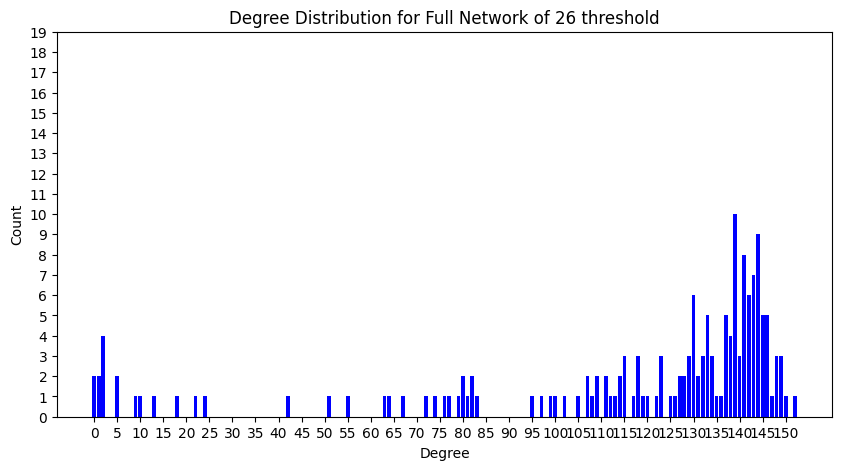

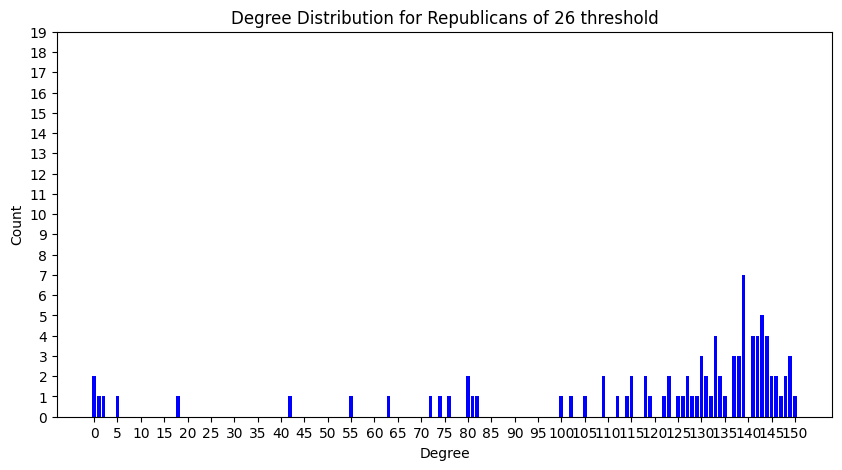

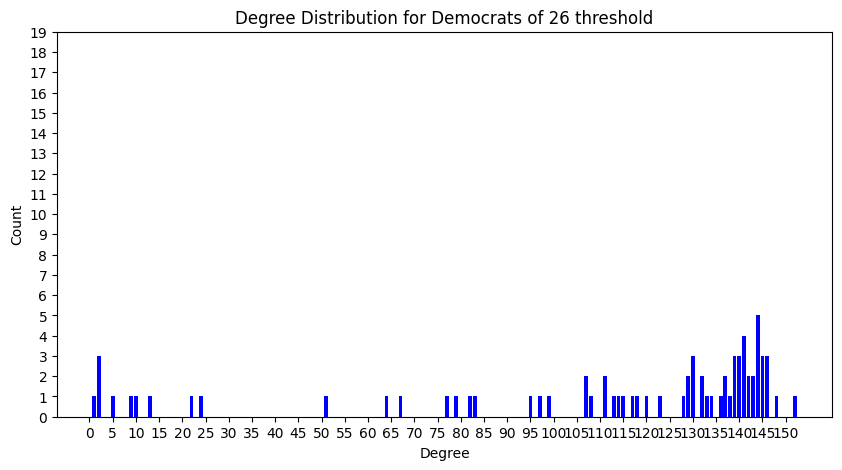

In [2232]:
import collections

# Get a list of degrees of all nodes in the graph
degrees = [degree for node, degree in G.degree()]
degrees_r = [degree for node, degree in G.degree() if G.nodes[node]['party'] == 'R']
degrees_d = [degree for node, degree in G.degree() if G.nodes[node]['party'] == 'D']

# Count the frequency of each degree value
degree_count = collections.Counter(degrees)
deg, cnt = zip(*degree_count.items())
plt.figure(figsize=(10, 5))  # Set the figure size as needed
plt.bar(deg, cnt, width=0.80, color='b')

plt.title("Degree Distribution for Full Network of 26 threshold")
plt.ylabel("Count")
plt.xlabel("Degree")
plt.xticks(range(0, max(deg) + 1, 5))  # Set x-ticks to show all degree values
plt.yticks(range(0, 20))

# Optionally set a log scale for the y-axis if the data spans several orders of magnitude
# plt.yscale('log')

plt.show()

# Count the frequency of each degree value
degree_count = collections.Counter(degrees_r)
deg, cnt = zip(*degree_count.items())
plt.figure(figsize=(10, 5))  # Set the figure size as needed
plt.bar(deg, cnt, width=0.80, color='b')

plt.title("Degree Distribution for Republicans of 26 threshold")
plt.ylabel("Count")
plt.xlabel("Degree")
plt.xticks(range(0, max(deg) + 1, 5))  # Set x-ticks to show all degree values
plt.yticks(range(0, 20))

# Optionally set a log scale for the y-axis if the data spans several orders of magnitude
# plt.yscale('log')

plt.show()

# Count the frequency of each degree value
degree_count = collections.Counter(degrees_d)
deg, cnt = zip(*degree_count.items())
plt.figure(figsize=(10, 5))  # Set the figure size as needed
plt.bar(deg, cnt, width=0.80, color='b')

plt.title("Degree Distribution for Democrats of 26 threshold")
plt.ylabel("Count")
plt.xlabel("Degree")
plt.xticks(range(0, max(deg) + 1, 5))  # Set x-ticks to show all degree values
plt.yticks(range(0, 20))

# Optionally set a log scale for the y-axis if the data spans several orders of magnitude
# plt.yscale('log')

plt.show()


In [2300]:
# def affiliation_degree_dist(party, df_data, metric):
#     sorted_df = df_data.sort_values(by='affiliation_score')
#     plt.figure(figsize=(10, 6))  # Set the figure size
#     plt.scatter(sorted_df['affiliation_score'], sorted_df[metric], alpha=0.7)  # alpha for transparency
#     plt.title(str(party+' Affiliation Score vs. '+ metric))
#     plt.xlabel('Affiliation Score')
#     plt.ylabel(metric)
#     plt.grid(True)  # Enable grid for better readability
#     plt.show()
#     plt.figure(figsize=(10, 6))
#     plt.plot(sorted_df['affiliation_score'], sorted_df[metric], marker='o', linestyle='-')  # 'o' for points
#     plt.title(str(party+' Affiliation Score vs. '+ metric))
#     plt.xlabel('Affiliation Score')
#     plt.ylabel(metric)
#     plt.grid(True)
#     plt.show()

def affiliation_degree_dist(party, df_data, metric, title_name = None):
    if title_name == None:
        title = str(party+ ' Affiliation Score vs. '+ metric)
    else:
        title = str(party+ ' Affiliation Score vs. '+ title_name)
    sorted_df = df_data.sort_values(by='affiliation_score')
    x = sorted_df['affiliation_score']
    y = sorted_df[metric]

    plt.figure(figsize=(10, 4))
    plt.scatter(x, y, alpha=0.7)
    
    # Add line of best fit
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color='red', label=f'Best Fit Line (slope={m:.2f})')
    
    plt.title(title)
    plt.xlabel('Affiliation Score')
    plt.ylabel(metric)
    plt.grid(True)
    # plt.legend()
    plt.show()

    # Line plot version too
    plt.figure(figsize=(10, 4))
    plt.plot(x, y, marker='o', linestyle='-')
    
    # Best fit line again
    plt.plot(x, m * x + b, color='red', label=f'Best Fit Line (slope={m:.2f})')
    
    plt.title(title)
    plt.xlabel('Affiliation Score')
    plt.ylabel(metric)
    plt.grid(True)
    # plt.legend()
    plt.show()


In [2301]:
republican_df = df_data[df_data['party'] == "R"]
democratic_df = df_data[df_data['party'] == "D"]

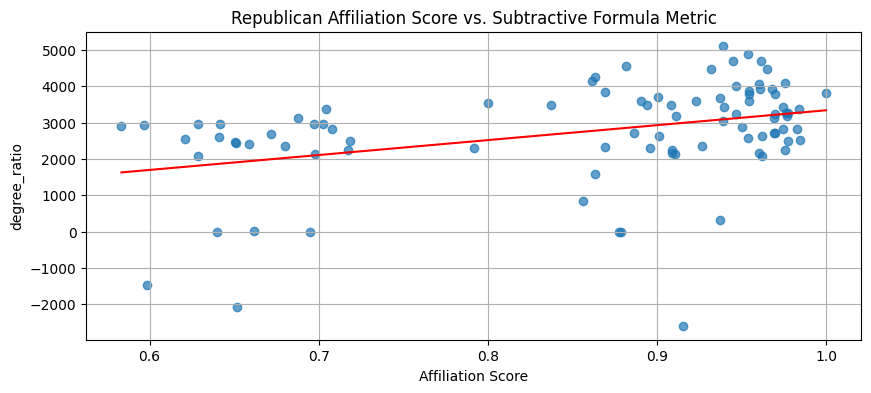

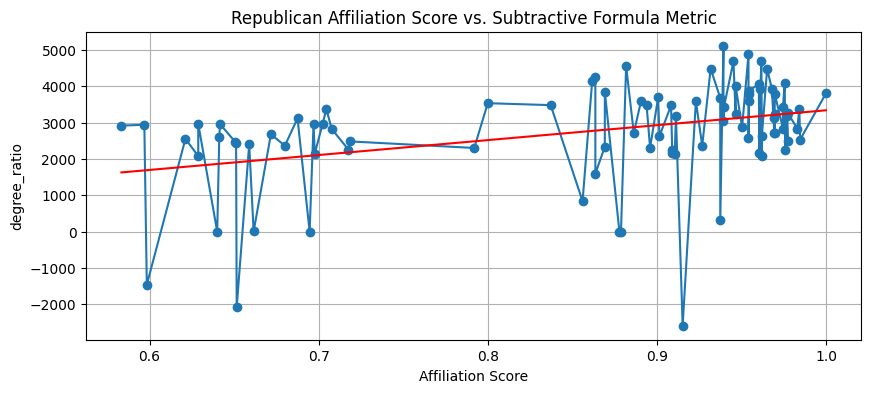

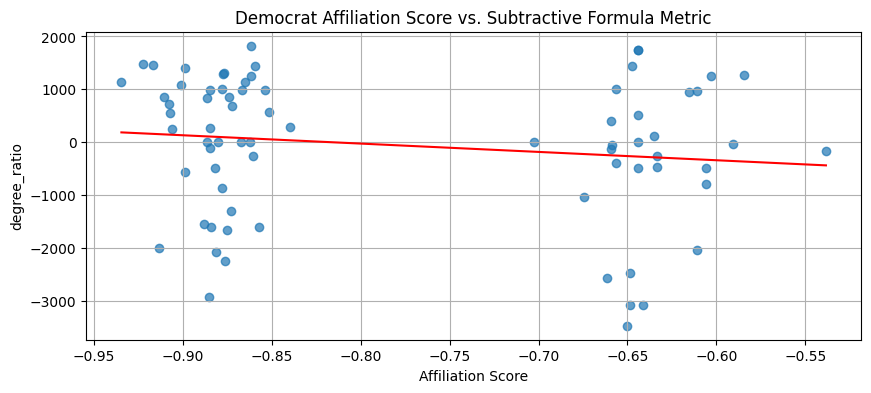

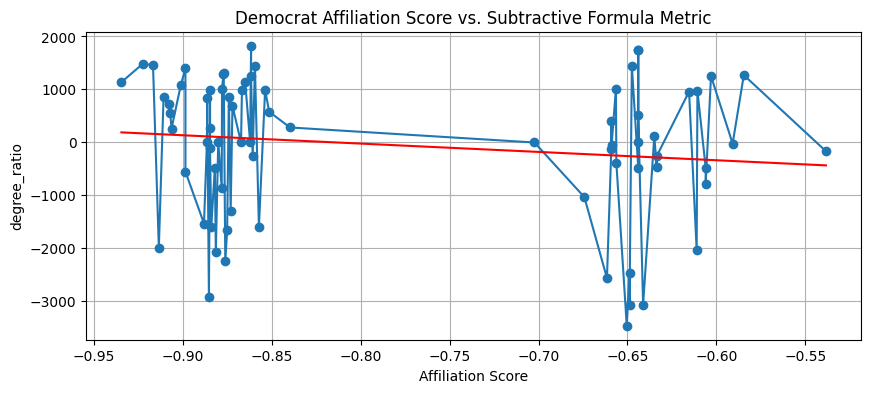

In [2302]:
affiliation_degree_dist("Republican",republican_df, 'degree_ratio', 'Subtractive Formula Metric')
affiliation_degree_dist("Democrat",democratic_df, 'degree_ratio', 'Subtractive Formula Metric')

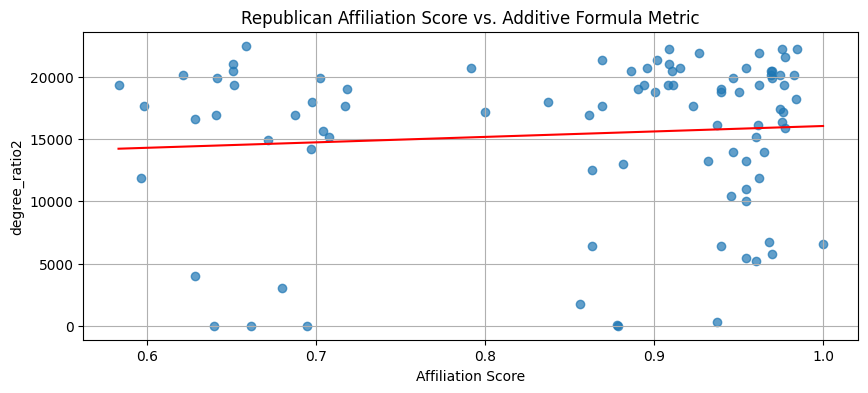

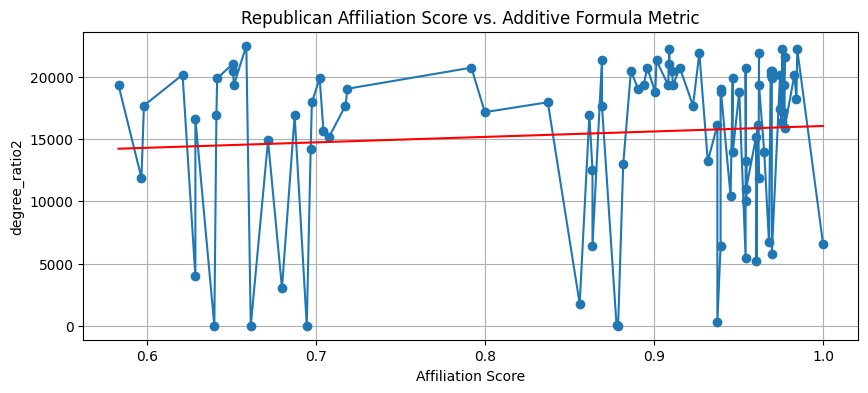

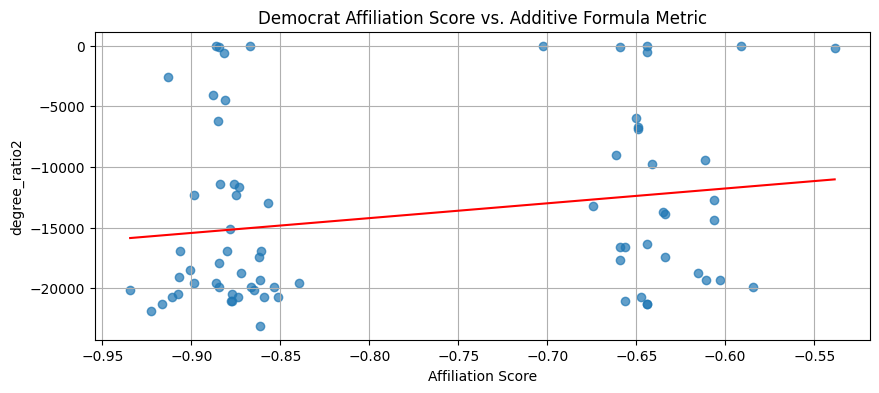

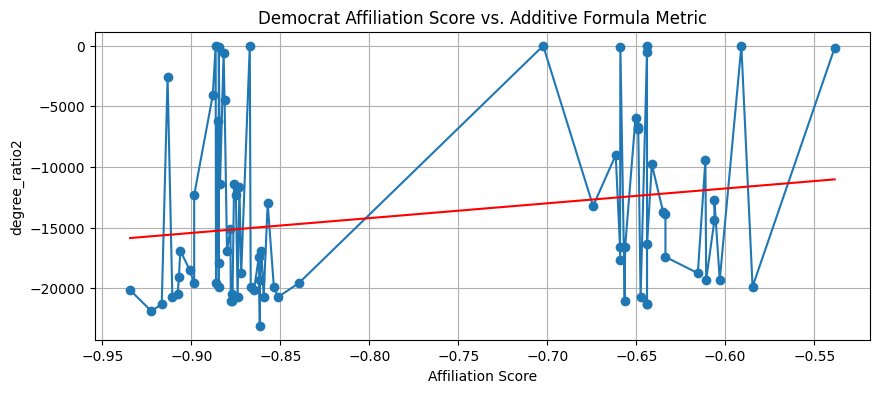

In [2303]:
affiliation_degree_dist("Republican",republican_df, 'degree_ratio2', 'Additive Formula Metric')
affiliation_degree_dist("Democrat",democratic_df, 'degree_ratio2', 'Additive Formula Metric')

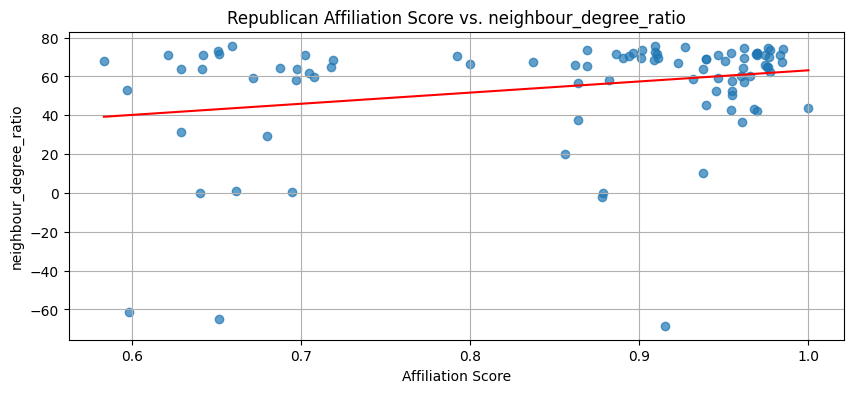

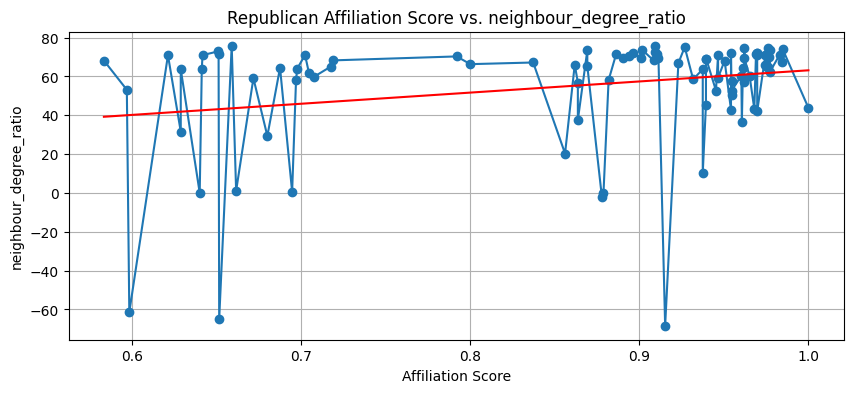

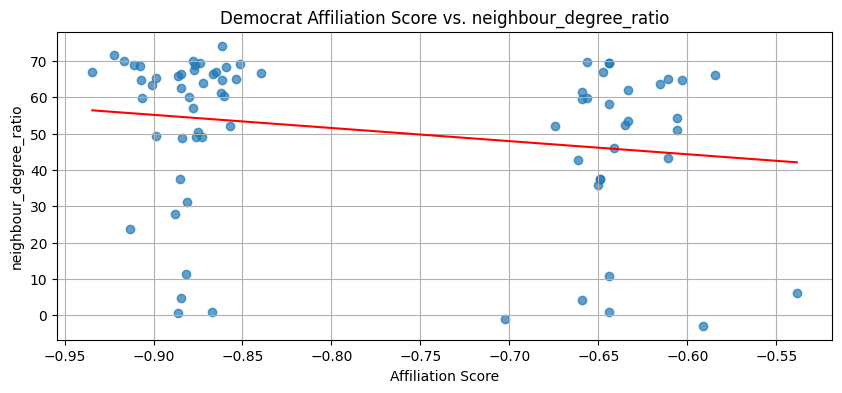

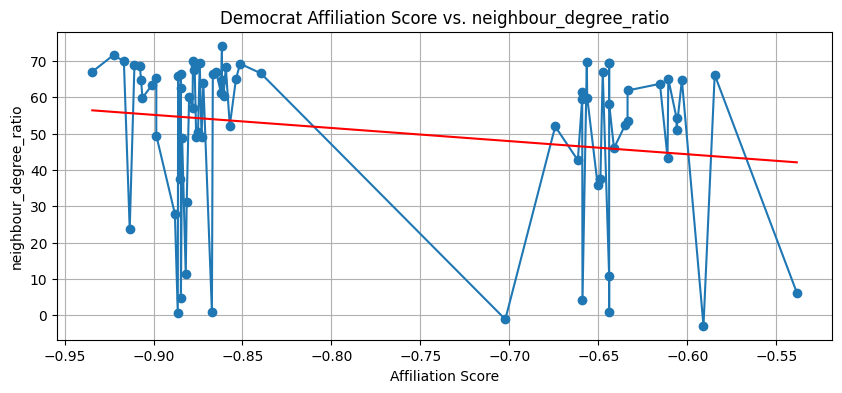

In [2304]:
affiliation_degree_dist("Republican",republican_df, 'neighbour_degree_ratio')
affiliation_degree_dist("Democrat",democratic_df, 'neighbour_degree_ratio')

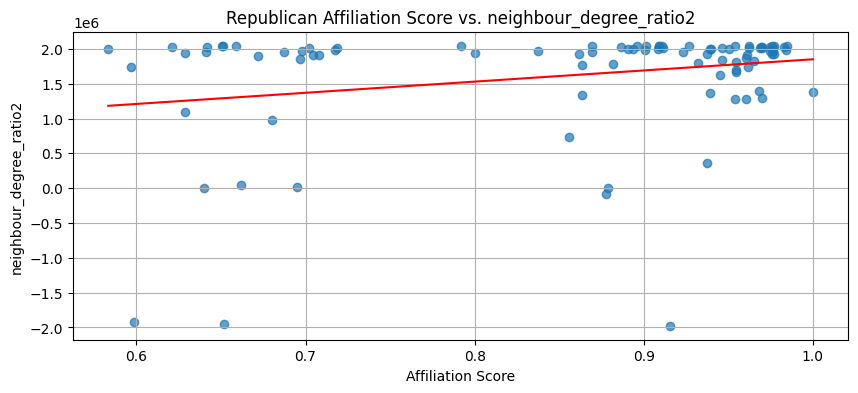

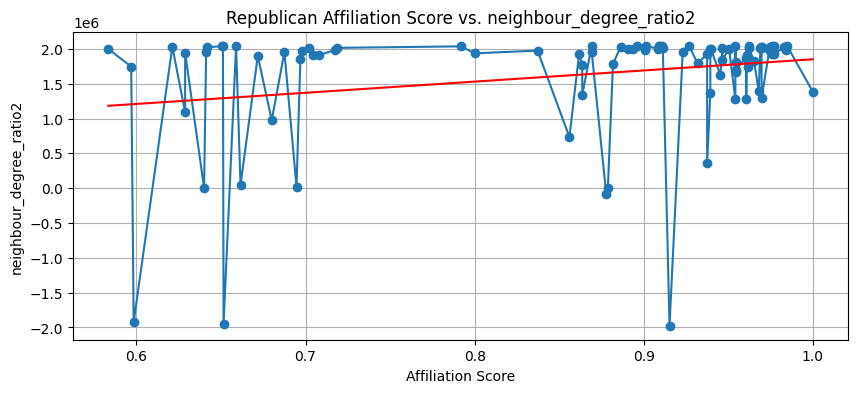

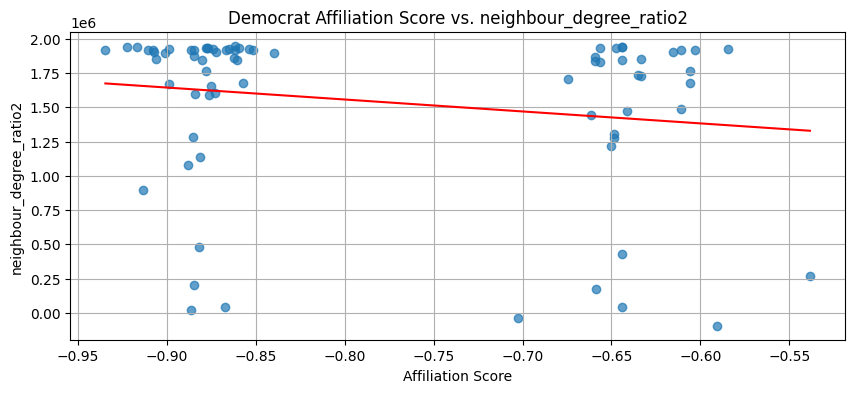

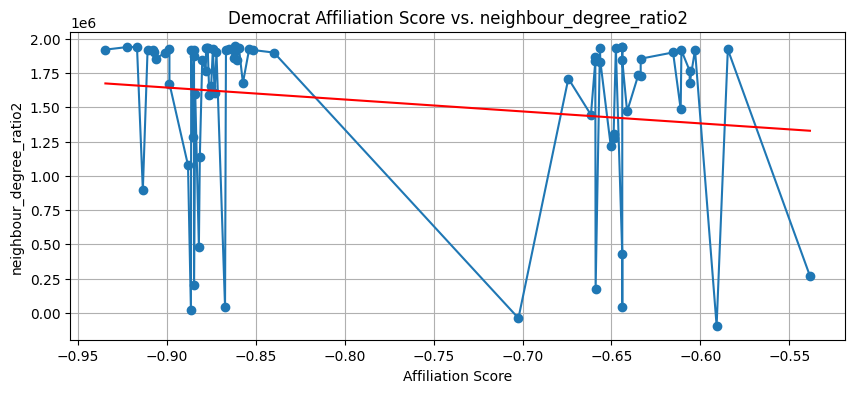

In [2305]:
affiliation_degree_dist("Republican",republican_df, 'neighbour_degree_ratio2')
affiliation_degree_dist("Democrat",democratic_df, 'neighbour_degree_ratio2')

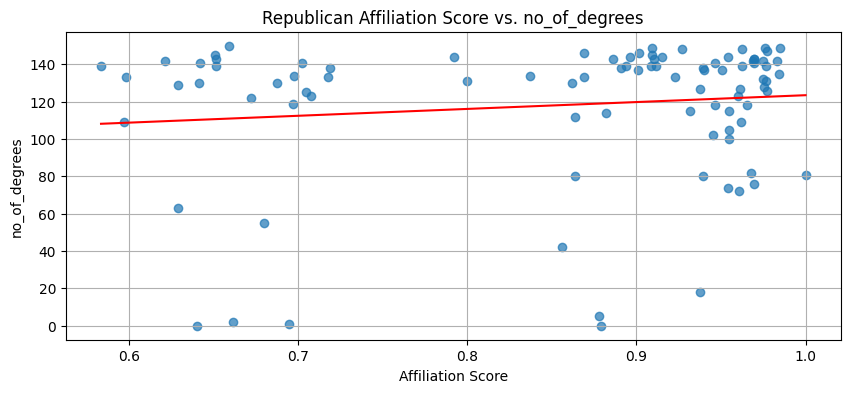

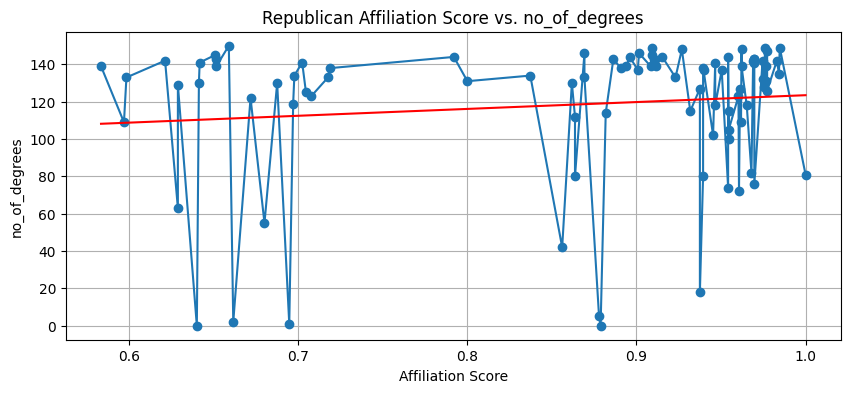

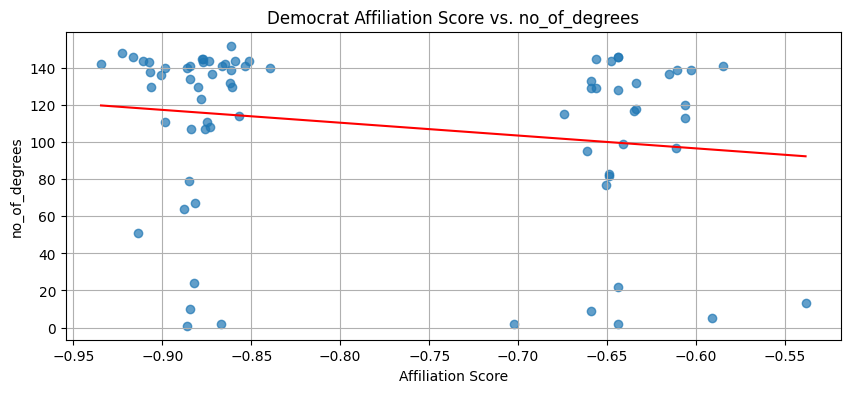

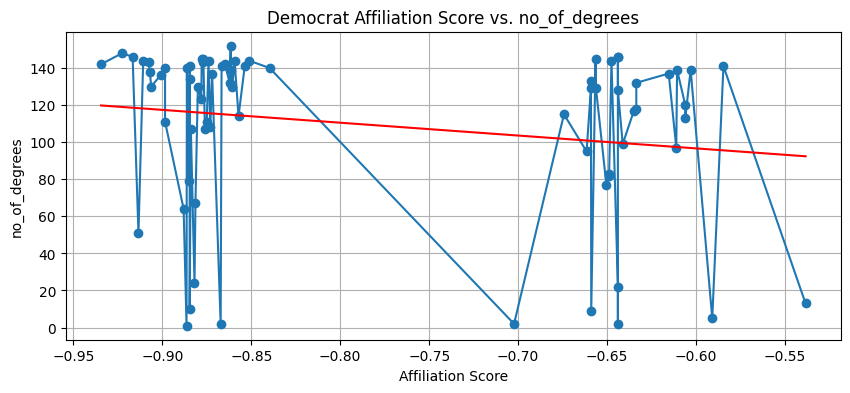

In [2306]:
affiliation_degree_dist("Republican",republican_df, 'no_of_degrees')
affiliation_degree_dist("Democrat",democratic_df, 'no_of_degrees')

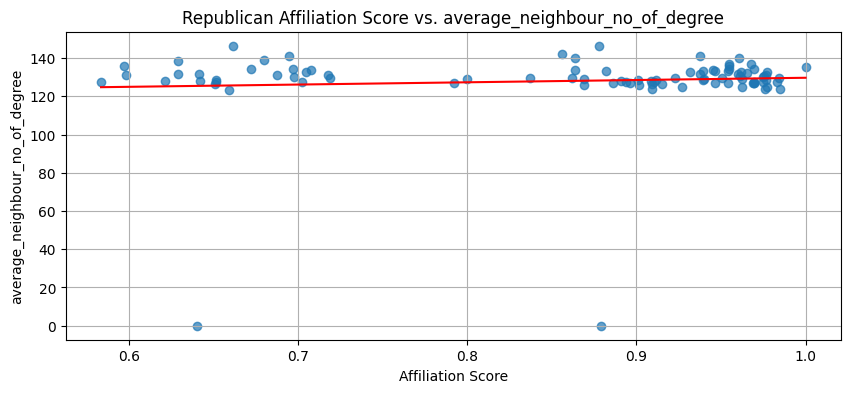

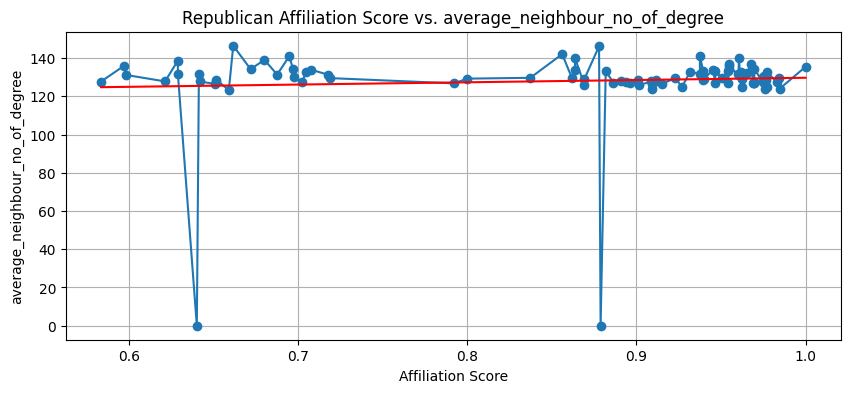

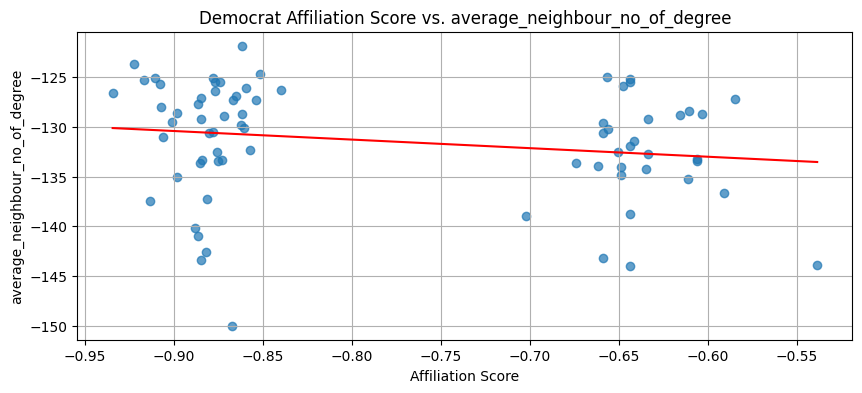

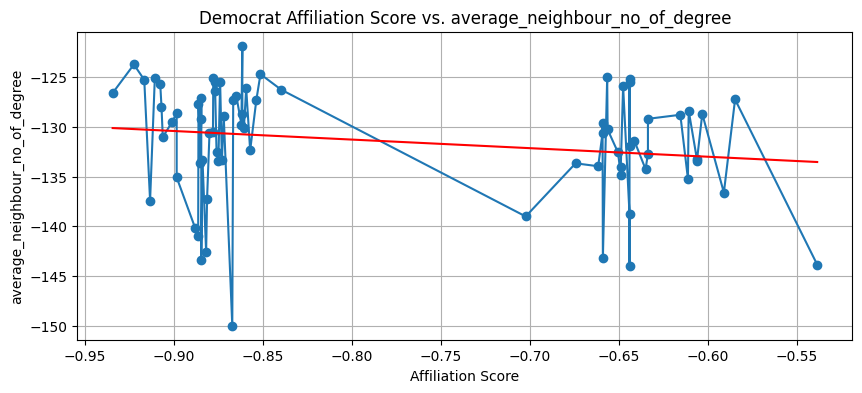

In [2307]:
affiliation_degree_dist("Republican",republican_df, 'average_neighbour_no_of_degree')
affiliation_degree_dist("Democrat",democratic_df, 'average_neighbour_no_of_degree')

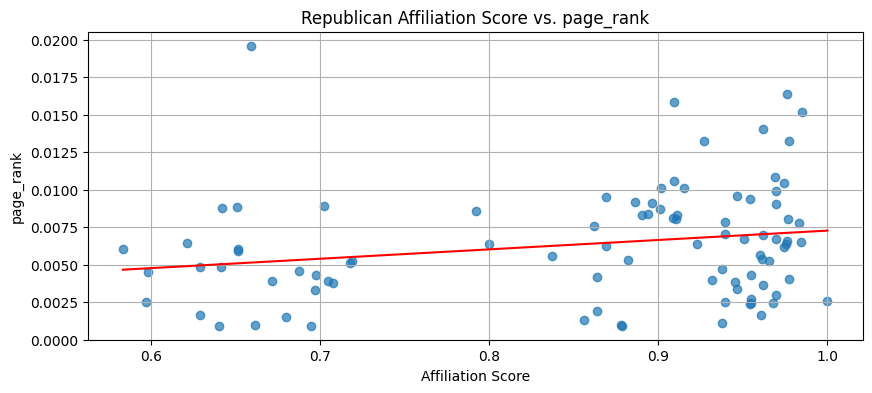

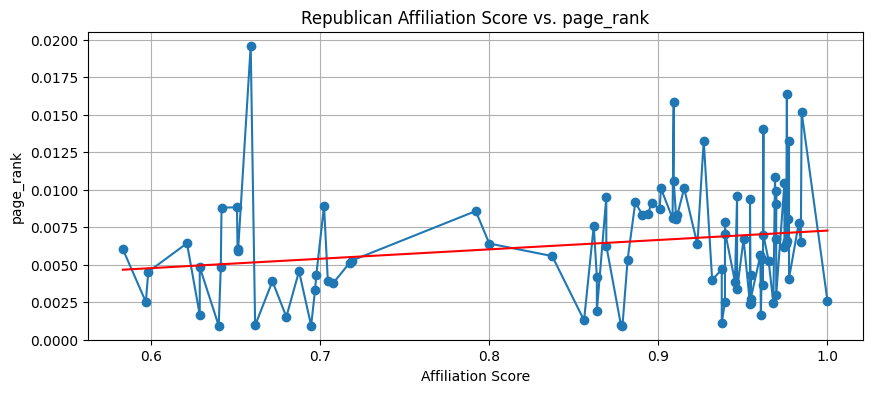

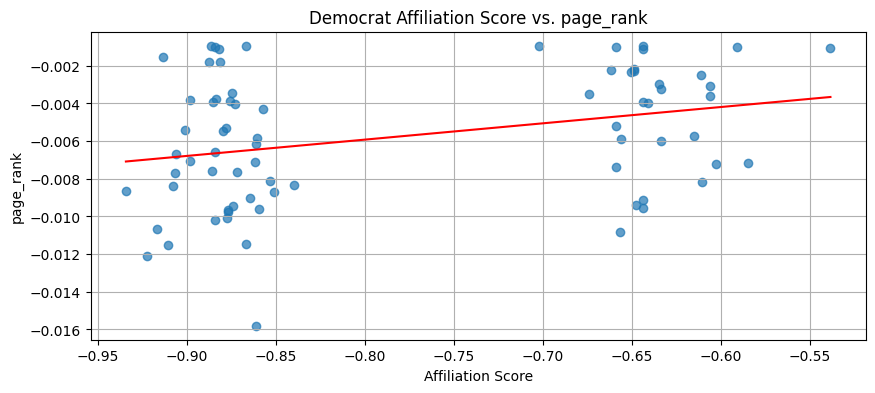

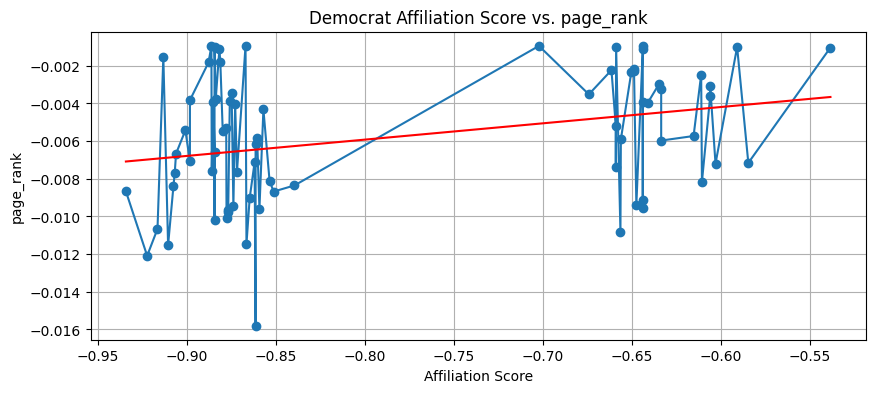

In [2308]:
affiliation_degree_dist("Republican",republican_df, 'page_rank')
affiliation_degree_dist("Democrat",democratic_df, 'page_rank')

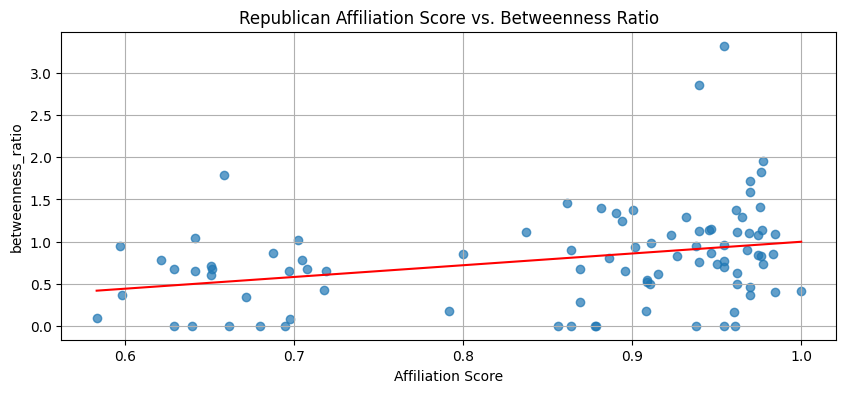

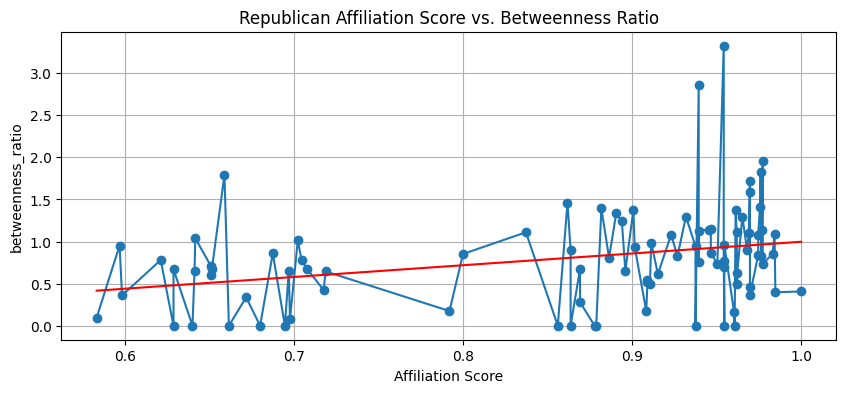

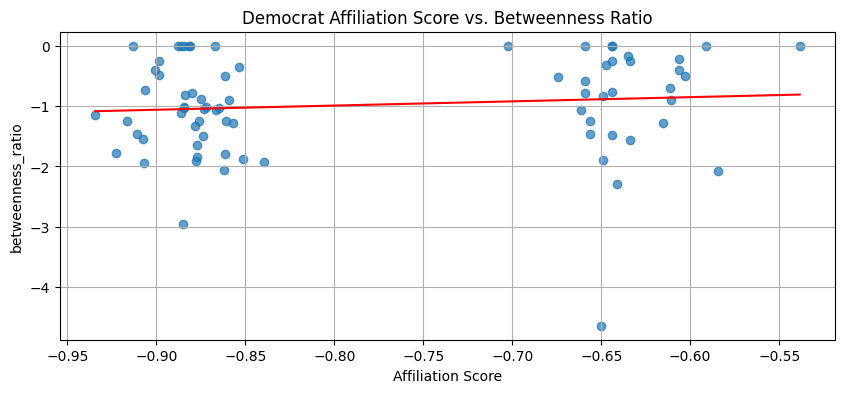

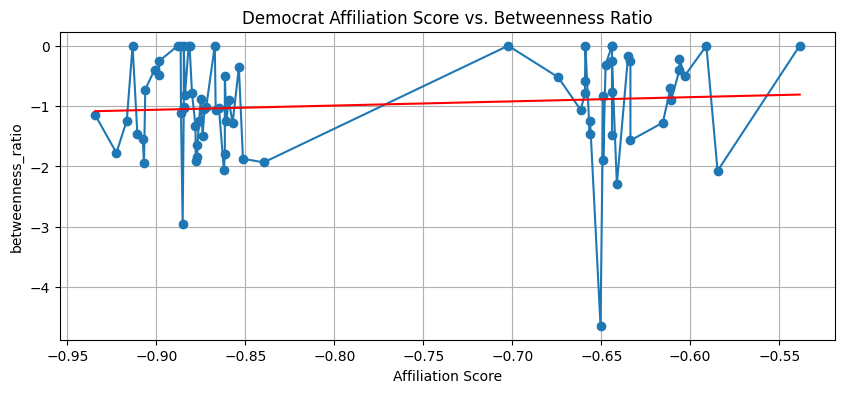

In [2309]:
affiliation_degree_dist("Republican",republican_df, 'betweenness_ratio', 'Betweenness Ratio')
affiliation_degree_dist("Democrat",democratic_df, 'betweenness_ratio', 'Betweenness Ratio')

In [2310]:
from scipy.stats import pearsonr, spearmanr

def calculate_loyalty_groundtruth_correlation(df_data, loyalty_column='loyalty_score', groundtruth_column='affiliation_score'):
    """
    Calculates Pearson correlation between loyalty metric and ground truth affiliation scores.
    
    Parameters:
        df_data: DataFrame containing loyalty scores and affiliation scores
        loyalty_column: Name of column with loyalty scores
        groundtruth_column: Name of column with ground truth affiliation scores

    Returns:
        correlation (r), p-value
    """
    # Drop any missing values just in case
    valid_data = df_data.dropna(subset=[loyalty_column, groundtruth_column])

    x = valid_data[loyalty_column].values
    y = valid_data[groundtruth_column].values

    r, p_value = pearsonr(x, y)
    return r, p_value


In [2244]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='degree_ratio', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='degree_ratio', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")



Republican Pearson Correlation (r): 0.3763
P-value: 0.0002366
Democrat Pearson Correlation (r): -0.1473
P-value: 0.2137


In [2245]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='degree_ratio2', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='degree_ratio2', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")



Republican Pearson Correlation (r): 0.0877
P-value: 0.4086
Democrat Pearson Correlation (r): 0.2074
P-value: 0.07826


In [2246]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='degree_ratio3', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='degree_ratio3', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")



Republican Pearson Correlation (r): 0.1089
P-value: 0.3043
Democrat Pearson Correlation (r): -0.1659
P-value: 0.1607


In [2247]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='neighbour_degree_ratio', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='neighbour_degree_ratio', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.2529
P-value: 0.01556
Democrat Pearson Correlation (r): -0.2056
P-value: 0.08097


In [2248]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='neighbour_degree_ratio2', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='neighbour_degree_ratio2', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.2447
P-value: 0.01938
Democrat Pearson Correlation (r): -0.1797
P-value: 0.1283


In [2249]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='average_neighbour_no_of_degree', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='average_neighbour_no_of_degree', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")



Republican Pearson Correlation (r): 0.0766
P-value: 0.4703
Democrat Pearson Correlation (r): -0.1870
P-value: 0.1132


In [2250]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='no_of_degrees', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='no_of_degrees', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")



Republican Pearson Correlation (r): 0.1239
P-value: 0.242
Democrat Pearson Correlation (r): -0.1885
P-value: 0.1102


In [ ]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='average_neighbour_same_comm_degree', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='average_neighbour_same_comm_degree', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.0766
P-value: 0.4703
Democrat Pearson Correlation (r): -0.1870
P-value: 0.1132


In [ ]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='global_betweenness', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='global_betweenness', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.0390
P-value: 0.7137
Democrat Pearson Correlation (r): -0.1406
P-value: 0.2354


In [ ]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='party_betweenness', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='party_betweenness', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.0854
P-value: 0.421
Democrat Pearson Correlation (r): -0.1189
P-value: 0.3162


In [ ]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='betweenness_ratio', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='betweenness_ratio', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.3040
P-value: 0.003399
Democrat Pearson Correlation (r): 0.1058
P-value: 0.3731


In [ ]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='page_rank', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='page_rank', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")



Republican Pearson Correlation (r): 0.2119
P-value: 0.04377
Democrat Pearson Correlation (r): 0.3116
P-value: 0.007288


In [ ]:
def calculate_internal_external_degrees(G, df_data):
    """
    Calculates internal and external degrees for each node based on party affiliation.
    
    Parameters:
        G: Graph
        df_data: DataFrame with 'current_twitter_name' and 'party'
    
    Returns:
        Updated df_data with 'internal_degree' and 'external_degree' columns
    """
    party_map = dict(zip(df_data['current_twitter_name'], df_data['party']))
    
    internal_degrees = {}
    external_degrees = {}

    for node in G.nodes():
        node_party = party_map.get(node, None)
        if node_party is None:
            continue  # skip nodes not in the dataframe

        internal = 0
        external = 0
        for neighbor in G.neighbors(node):
            neighbor_party = party_map.get(neighbor, None)
            if neighbor_party is None:
                continue
            if neighbor_party == node_party:
                internal += 1
            else:
                external += 1

        internal_degrees[node] = internal
        external_degrees[node] = external

    # Map back into df_data
    df_data = df_data.copy()
    df_data['internal_degree'] = df_data['current_twitter_name'].apply(lambda x: internal_degrees.get(x, 0))
    df_data['external_degree'] = df_data['current_twitter_name'].apply(lambda x: external_degrees.get(x, 0))

    return df_data


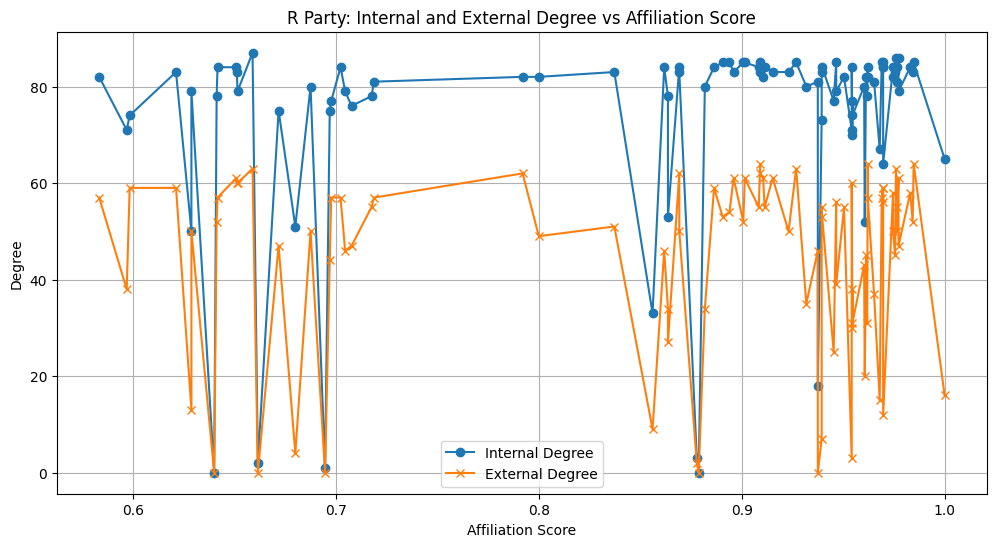

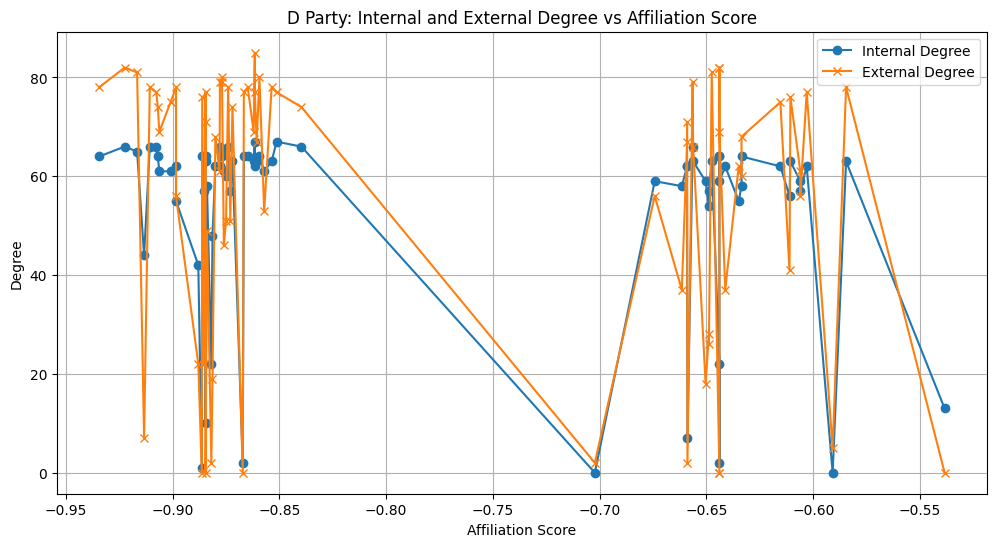

In [2180]:
# Suppose your df_data has columns:
# - 'party'
# - 'current_twitter_name'
# - 'internal_degree'
# - 'external_degree'
# - 'affiliation_score'
import matplotlib.pyplot as plt

def plot_internal_external_by_affiliation(df_data, party, internal_col='internal_degree', external_col='external_degree', affiliation_col='affiliation_score'):
    """
    Plots internal and external degree vs affiliation score for nodes of a given party.
    """
    # 1. Filter for the correct party
    party_df = df_data[df_data['party'] == party].copy()

    # 2. Sort by affiliation score
    party_df = party_df.sort_values(by=affiliation_col)

    # 3. Plot
    plt.figure(figsize=(12, 6))
    plt.plot(party_df[affiliation_col], party_df[internal_col], label='Internal Degree', marker='o')
    plt.plot(party_df[affiliation_col], party_df[external_col], label='External Degree', marker='x')
    
    plt.title(f"{party} Party: Internal and External Degree vs Affiliation Score")
    plt.xlabel('Affiliation Score')
    plt.ylabel('Degree')
    plt.legend()
    plt.grid(True)
    plt.show()


df_data = calculate_internal_external_degrees(G, df_data)

# Now your df_data has two new columns:
# - 'internal_degree'
# - 'external_degree'

# Now you can run the visualization function:
plot_internal_external_by_affiliation(df_data, party='R')
plot_internal_external_by_affiliation(df_data, party='D')



In [2211]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
df_data['total_degree'] = df_data['internal_degree'] / (df_data['internal_degree']+df_data['external_degree'])
republican_df = df_data[df_data['party'] == "R"]
democratic_df = df_data[df_data['party'] == "D"]
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='internal_degree', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='internal_degree', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.2100
P-value: 0.04578
Democrat Pearson Correlation (r): -0.1761
P-value: 0.1362


In [2212]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='external_degree', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='external_degree', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.0192
P-value: 0.8566
Democrat Pearson Correlation (r): -0.1862
P-value: 0.1147


In [2214]:
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(republican_df, loyalty_column='total_degree', groundtruth_column='affiliation_score')

print(f"Republican Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")
# Suppose your loyalty metric is stored in df_data['loyalty_score']
r, p = calculate_loyalty_groundtruth_correlation(democratic_df, loyalty_column='total_degree', groundtruth_column='affiliation_score')

print(f"Democrat Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p:.4g}")


Republican Pearson Correlation (r): 0.0241
P-value: 0.8228
Democrat Pearson Correlation (r): -0.0011
P-value: 0.9927


In [2184]:
import networkx as nx
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def calculate_core_numbers(G_full, df_data, republican_nodes, democrat_nodes):
    """
    Calculates core numbers on full graph and on party subgraphs separately.
    
    Adds columns:
    - 'global_core_number'
    - 'party_core_number'
    """
    # 1. Global core numbers (full graph)
    global_core = nx.core_number(G_full)

    # 2. Party subgraphs
    G_republican = G_full.subgraph(republican_nodes)
    G_democrat = G_full.subgraph(democrat_nodes)

    republican_core = nx.core_number(G_republican)
    democrat_core = nx.core_number(G_democrat)

    # 3. Map into DataFrame
    df_data = df_data.copy()

    df_data['global_core_number'] = df_data['current_twitter_name'].apply(lambda x: global_core.get(x, 0))

    def party_core_lookup(row):
        if row['party'] == 'R':
            return republican_core.get(row['current_twitter_name'], 0)
        else:
            return democrat_core.get(row['current_twitter_name'], 0)

    df_data['party_core_number'] = df_data.apply(party_core_lookup, axis=1)

    return df_data

def correlate_core_to_affiliation(df_data, core_col):
    """
    Calculates Pearson correlation between a core number column and affiliation score.
    """
    valid_data = df_data.dropna(subset=[core_col, 'affiliation_score'])
    x = valid_data[core_col].values
    y = valid_data['affiliation_score'].values
    r, p = pearsonr(x, y)
    return r, p

def plot_core_vs_affiliation(df_data, core_col, party_label='All'):
    """
    Plots core number vs affiliation score.
    """
    sorted_df = df_data.sort_values(by='affiliation_score')
    x = sorted_df['affiliation_score']
    y = sorted_df[core_col]

    plt.figure(figsize=(10,6))
    plt.scatter(x, y, alpha=0.7)
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color='red', label=f'Best Fit Line (slope={m:.2f})')

    plt.title(f"{party_label}: {core_col} vs Affiliation Score")
    plt.xlabel('Affiliation Score')
    plt.ylabel(core_col)
    plt.grid(True)
    plt.legend()
    plt.show()


Global Core vs Affiliation: r = 0.1094, p = 0.1633
Party Core vs Affiliation: r = 0.4670, p = 2.913e-10


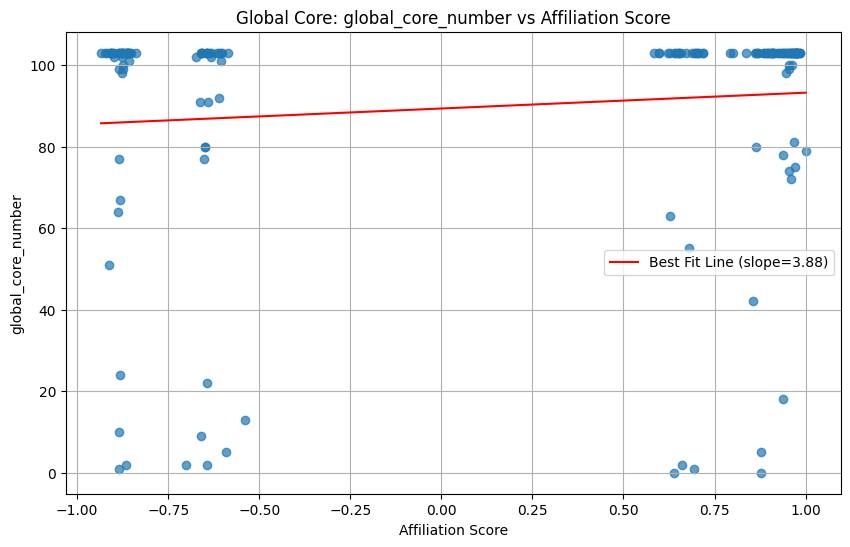

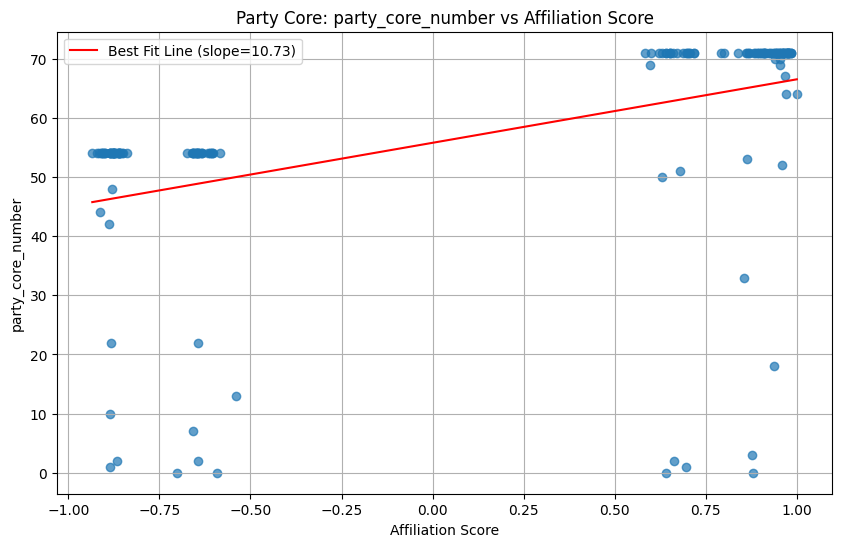

In [2185]:
# Suppose you have G_full, df_data, republican_nodes, democrat_nodes

# 1. Calculate core numbers
df_data = calculate_core_numbers(G, df_data, republican_df['current_twitter_name'].tolist(), democratic_df['current_twitter_name'].tolist())

# 2. Correlate and print
r_global, p_global = correlate_core_to_affiliation(df_data, 'global_core_number')
r_party, p_party = correlate_core_to_affiliation(df_data, 'party_core_number')

print(f"Global Core vs Affiliation: r = {r_global:.4f}, p = {p_global:.4g}")
print(f"Party Core vs Affiliation: r = {r_party:.4f}, p = {p_party:.4g}")

# 3. Plot
plot_core_vs_affiliation(df_data, 'global_core_number', party_label='Global Core')
plot_core_vs_affiliation(df_data, 'party_core_number', party_label='Party Core')


In [2186]:
import networkx as nx
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def calculate_core_numbers(G_full, df_data, republican_nodes, democrat_nodes):
    """
    Calculates core numbers on full graph and on party subgraphs separately.
    
    Adds columns:
    - 'global_core_number'
    - 'party_core_number'
    """
    # 1. Global core numbers (full graph)
    global_core = nx.core_number(G_full)

    # 2. Party subgraphs
    G_republican = G_full.subgraph(republican_nodes)
    G_democrat = G_full.subgraph(democrat_nodes)

    republican_core = nx.core_number(G_republican)
    democrat_core = nx.core_number(G_democrat)

    # 3. Map into DataFrame
    df_data = df_data.copy()

    df_data['global_core_number'] = df_data['current_twitter_name'].apply(lambda x: global_core.get(x, 0))
    
    def party_core_lookup(row):
        if row['party'] == 'R':
            return republican_core.get(row['current_twitter_name'], 0)
        else:
            return democrat_core.get(row['current_twitter_name'], 0)

    df_data['party_core_number'] = df_data.apply(party_core_lookup, axis=1)

    return df_data

def correlate_core_to_affiliation(df_data, core_col, party_label):
    """
    Calculates Pearson correlation between a core number column and affiliation score for a given party.
    """
    df_party = df_data[df_data['party'] == party_label]
    valid_data = df_party.dropna(subset=[core_col, 'affiliation_score'])

    x = valid_data[core_col].values
    y = valid_data['affiliation_score'].values

    r, p = pearsonr(x, y)
    return r, p

def plot_core_vs_affiliation(df_data, core_col, party_label):
    """
    Plots core number vs affiliation score for a given party.
    """
    df_party = df_data[df_data['party'] == party_label]
    sorted_df = df_party.sort_values(by='affiliation_score')

    x = sorted_df['affiliation_score']
    y = sorted_df[core_col]

    plt.figure(figsize=(10,6))
    plt.scatter(x, y, alpha=0.7)
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color='red', label=f'Best Fit Line (slope={m:.2f})')

    plt.title(f"{party_label} Party: {core_col} vs Affiliation Score")
    plt.xlabel('Affiliation Score')
    plt.ylabel(core_col)
    plt.grid(True)
    plt.legend()
    plt.show()


Republican Global Core vs Affiliation: r = 0.1527, p = 0.1485
Republican Party Core vs Affiliation: r = 0.1846, p = 0.0799
Democrat Global Core vs Affiliation: r = -0.1463, p = 0.2167
Democrat Party Core vs Affiliation: r = -0.1401, p = 0.2371


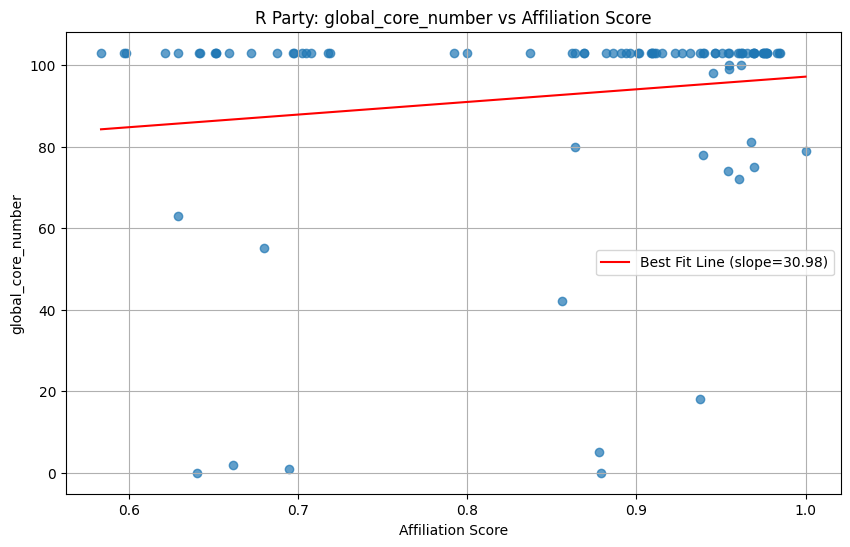

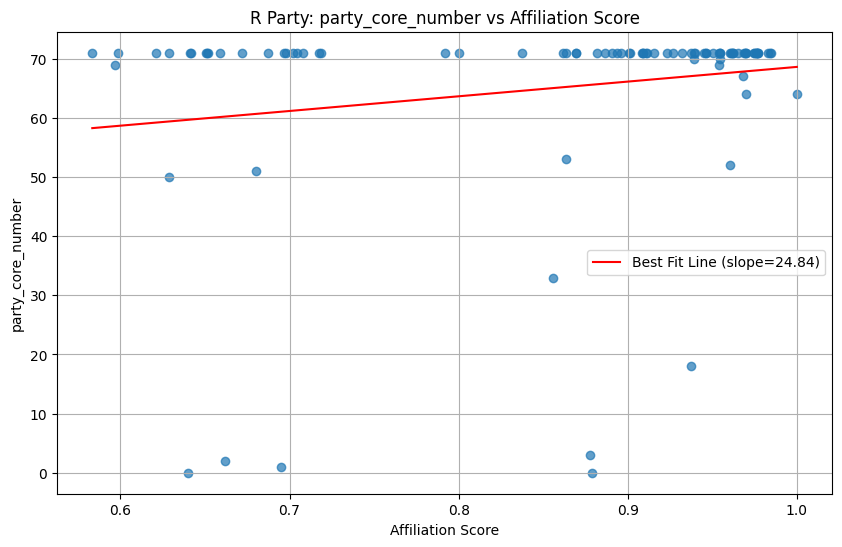

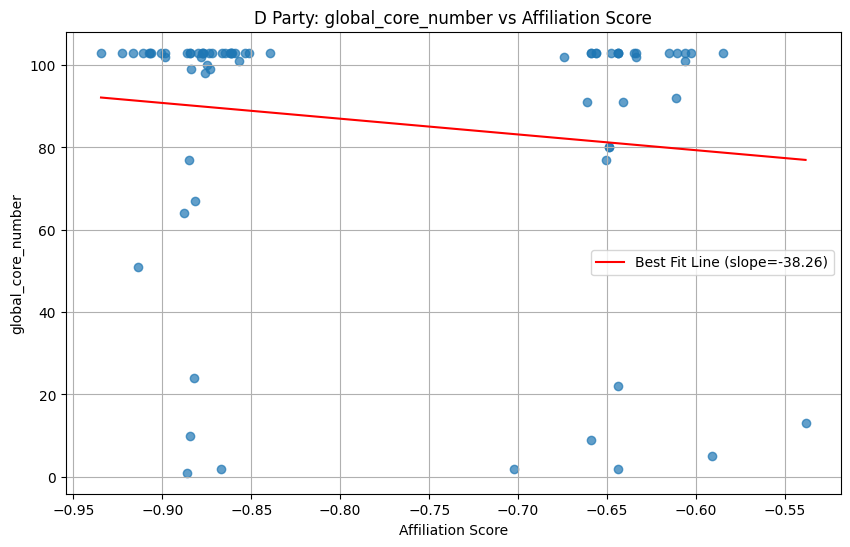

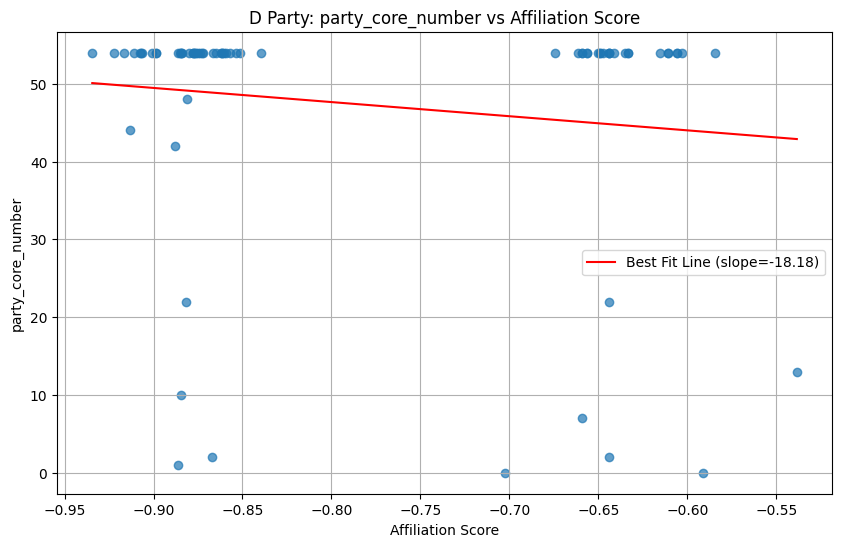

In [2187]:
# 1. Calculate core numbers
df_data = calculate_core_numbers(G, df_data, republican_df['current_twitter_name'].tolist(), democratic_df['current_twitter_name'].tolist())

# 2. Correlate and print per party
r_republican_global, p_republican_global = correlate_core_to_affiliation(df_data, 'global_core_number', 'R')
r_republican_party, p_republican_party = correlate_core_to_affiliation(df_data, 'party_core_number', 'R')

r_democrat_global, p_democrat_global = correlate_core_to_affiliation(df_data, 'global_core_number', 'D')
r_democrat_party, p_democrat_party = correlate_core_to_affiliation(df_data, 'party_core_number', 'D')

print(f"Republican Global Core vs Affiliation: r = {r_republican_global:.4f}, p = {p_republican_global:.4g}")
print(f"Republican Party Core vs Affiliation: r = {r_republican_party:.4f}, p = {p_republican_party:.4g}")

print(f"Democrat Global Core vs Affiliation: r = {r_democrat_global:.4f}, p = {p_democrat_global:.4g}")
print(f"Democrat Party Core vs Affiliation: r = {r_democrat_party:.4f}, p = {p_democrat_party:.4g}")

# 3. Plot per party
plot_core_vs_affiliation(df_data, 'global_core_number', party_label='R')
plot_core_vs_affiliation(df_data, 'party_core_number', party_label='R')

plot_core_vs_affiliation(df_data, 'global_core_number', party_label='D')
plot_core_vs_affiliation(df_data, 'party_core_number', party_label='D')


In [2188]:
def calculate_neighbor_affiliation_purity(G, df_data):
    """
    Calculates the average affiliation score of each node's neighbors.
    
    Parameters:
        G: Graph (networkx)
        df_data: DataFrame with 'current_twitter_name' and 'affiliation_score'
    
    Returns:
        Updated df_data with a new column: 'neighbor_affiliation_purity'
    """
    # Map node -> affiliation score
    affiliation_map = dict(zip(df_data['current_twitter_name'], df_data['affiliation_score']))

    neighbor_purity = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if not neighbors:
            neighbor_purity[node] = 0.0  # No neighbors, neutral purity
            continue
        
        # Get valid affiliation scores for neighbors (skip missing ones)
        neighbor_scores = [abs(affiliation_map.get(neighbor)) for neighbor in neighbors if affiliation_map.get(neighbor) is not None]
        
        if neighbor_scores:
            avg_score = sum(neighbor_scores) / len(neighbor_scores)
            neighbor_purity[node] = avg_score
        else:
            neighbor_purity[node] = 0.0  # No valid neighbors
        
    # Add to DataFrame
    df_data = df_data.copy()
    df_data['neighbor_affiliation_purity'] = df_data['current_twitter_name'].apply(lambda x: neighbor_purity.get(x, 0.0))
    
    return df_data


In [2189]:
def calculate_sameparty_neighbor_affiliation_purity(G, df_data):
    """
    Calculates the average affiliation score of each node's same-party neighbors.
    
    Parameters:
        G: Graph (networkx)
        df_data: DataFrame with 'current_twitter_name', 'party', and 'affiliation_score'
    
    Returns:
        Updated df_data with a new column: 'sameparty_neighbor_affiliation_purity'
    """
    # Map node -> affiliation score
    affiliation_map = dict(zip(df_data['current_twitter_name'], df_data['affiliation_score']))
    # Map node -> party
    party_map = dict(zip(df_data['current_twitter_name'], df_data['party']))

    neighbor_purity = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        node_party = party_map.get(node, None)

        if node_party is None or not neighbors:
            neighbor_purity[node] = 0.0  # No party or no neighbors
            continue
        
        # Get valid same-party neighbor affiliation scores
        neighbor_scores = [
            affiliation_map.get(neighbor)
            for neighbor in neighbors
            if party_map.get(neighbor) == node_party and affiliation_map.get(neighbor) is not None
        ]

        if neighbor_scores:
            avg_score = sum(neighbor_scores) / len(neighbor_scores)
            neighbor_purity[node] = avg_score
        else:
            neighbor_purity[node] = 0.0  # No valid same-party neighbors
        
    # Add to DataFrame
    df_data = df_data.copy()
    df_data['sameparty_neighbor_affiliation_purity'] = df_data['current_twitter_name'].apply(lambda x: neighbor_purity.get(x, 0.0))
    
    return df_data


In [2190]:
# Apply to your graph and df_data
df_data = calculate_neighbor_affiliation_purity(G, df_data)
df_data = calculate_sameparty_neighbor_affiliation_purity(G, df_data)

# Now df_data has a new column:
# 'sameparty_neighbor_affiliation_purity'


# Now your df_data has a new column:
# 'neighbor_affiliation_purity'
republican_df = df_data[df_data['party'] == "R"]
democratic_df = df_data[df_data['party'] == "D"]

In [2191]:
r, p = pearsonr(republican_df['neighbor_affiliation_purity'], republican_df['affiliation_score'])
print(f"Neighbor Affiliation Purity vs Affiliation Score: r = {r:.4f}, p = {p:.4g}")
r, p = pearsonr(democratic_df['neighbor_affiliation_purity'], democratic_df['affiliation_score'])
print(f"Neighbor Affiliation Purity vs Affiliation Score: r = {r:.4f}, p = {p:.4g}")


Neighbor Affiliation Purity vs Affiliation Score: r = 0.1357, p = 0.1998
Neighbor Affiliation Purity vs Affiliation Score: r = -0.0244, p = 0.8373


In [2192]:
r, p = pearsonr(republican_df['sameparty_neighbor_affiliation_purity'], republican_df['affiliation_score'])
print(f"Neighbor Affiliation Purity vs Affiliation Score: r = {r:.4f}, p = {p:.4g}")
r, p = pearsonr(democratic_df['sameparty_neighbor_affiliation_purity'], democratic_df['affiliation_score'])
print(f"Neighbor Affiliation Purity vs Affiliation Score: r = {r:.4f}, p = {p:.4g}")



Neighbor Affiliation Purity vs Affiliation Score: r = 0.1207, p = 0.2544
Neighbor Affiliation Purity vs Affiliation Score: r = 0.1559, p = 0.1877


In [2258]:
import networkx as nx

def apply_hits_scores(df_data, G):
    """
    Calculates HITS authority and hub scores for each node in the graph.
    Adjusts Democrat scores to be negative for standardization.
    
    Parameters:
        df_data: DataFrame with 'current_twitter_name' and 'party'
        G: Graph (networkx)

    Returns:
        Updated df_data with new columns: 'authority_score', 'hub_score'
    """
    # Calculate HITS scores
    hits_hub, hits_auth = nx.hits(G, normalized=True)

    # Map into DataFrame
    df_data = df_data.copy()

    # Authority scores
    df_data['raw_authority'] = df_data['current_twitter_name'].apply(lambda x: hits_auth.get(x, 0.0))
    df_data['authority_score'] = np.where(
        df_data['party'] == 'R',
        df_data['raw_authority'],
        -df_data['raw_authority']
    )

    # Hub scores
    df_data['raw_hub'] = df_data['current_twitter_name'].apply(lambda x: hits_hub.get(x, 0.0))
    df_data['hub_score'] = np.where(
        df_data['party'] == 'R',
        df_data['raw_hub'],
        -df_data['raw_hub']
    )

    # Drop raw columns if you want to keep it clean
    df_data.drop(columns=['raw_authority', 'raw_hub'], inplace=True)

    return df_data


In [2259]:
def apply_party_hits_scores(G_full, df_data, republican_nodes, democrat_nodes):
    """
    Calculates HITS authority scores separately on Republican and Democrat subgraphs.
    Adjusts Democrat scores to be negative.
    
    Parameters:
        G_full: Full shared-following graph
        df_data: Full dataframe with 'current_twitter_name' and 'party'
        republican_nodes: List of Republican node names
        democrat_nodes: List of Democrat node names
    
    Returns:
        Updated df_data with new column: 'party_hits_authority'
    """
    # 1. Build party subgraphs
    G_republican = G_full.subgraph(republican_nodes)
    G_democrat = G_full.subgraph(democrat_nodes)

    # 2. Calculate HITS separately
    hits_hub_R, hits_auth_R = nx.hits(G_republican, normalized=True)
    hits_hub_D, hits_auth_D = nx.hits(G_democrat, normalized=True)

    # 3. Merge into one authority dictionary
    combined_auth = {}
    combined_auth.update(hits_auth_R)
    combined_auth.update(hits_auth_D)

    # 4. Map into df_data
    df_data = df_data.copy()
    df_data['raw_party_hits_authority'] = df_data['current_twitter_name'].apply(lambda x: combined_auth.get(x, 0.0))

    # 5. Flip Democrats' scores to negative
    df_data['party_hits_authority'] = np.where(
        df_data['party'] == 'R',
        df_data['raw_party_hits_authority'],
        -df_data['raw_party_hits_authority']
    )

    # Drop raw if you want clean DataFrame
    df_data.drop(columns=['raw_party_hits_authority'], inplace=True)

    return df_data


In [2260]:

# Apply the function
df_data = apply_hits_scores(df_data, G)

# Apply it:
df_data = apply_party_hits_scores(G, df_data, republican_df['current_twitter_name'].tolist(), democratic_df['current_twitter_name'].tolist())

# Now your df_data has:
# 'party_hits_authority'
# (positive for Republicans, negative for Democrats)

republican_df = df_data[df_data['party'] == "R"]
democratic_df = df_data[df_data['party'] == "D"]
# Now your df_data has:
# - 'authority_score'
# - 'hub_score'

# You can now correlate them to affiliation score like you did with PageRank!


In [2261]:

# Authority
r_auth, p_auth = pearsonr(republican_df['authority_score'], republican_df['affiliation_score'])
print(f"Republican Authority Score vs Affiliation: r = {r_auth:.4f}, p = {p_auth:.4g}")
r_auth, p_auth = pearsonr(democratic_df['authority_score'], democratic_df['affiliation_score'])
print(f"Democrat Authority Score vs Affiliation: r = {r_auth:.4f}, p = {p_auth:.4g}")



Republican Authority Score vs Affiliation: r = 0.2280, p = 0.02974
Democrat Authority Score vs Affiliation: r = 0.3351, p = 0.003752


In [2262]:
r_party_hits, p_party_hits = pearsonr(republican_df['party_hits_authority'], republican_df['affiliation_score'])
print(f"Republican Party-Only HITS Authority vs Affiliation Score: r = {r_party_hits:.4f}, p = {p_party_hits:.4g}")
r_party_hits, p_party_hits = pearsonr(democratic_df['party_hits_authority'], democratic_df['affiliation_score'])
print(f"Democrat Party-Only HITS Authority vs Affiliation Score: r = {r_party_hits:.4f}, p = {p_party_hits:.4g}")


Republican Party-Only HITS Authority vs Affiliation Score: r = 0.2816, p = 0.006852
Democrat Party-Only HITS Authority vs Affiliation Score: r = 0.3876, p = 0.0007033


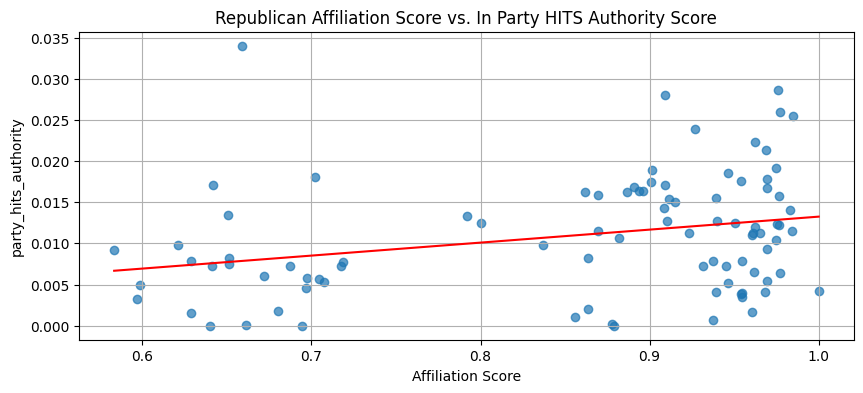

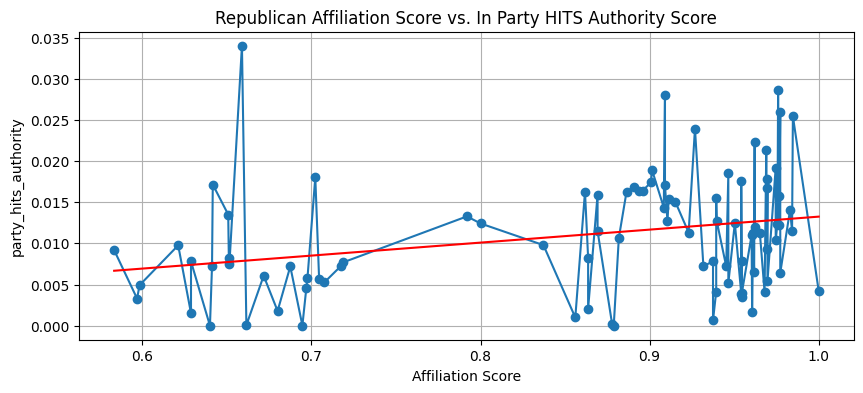

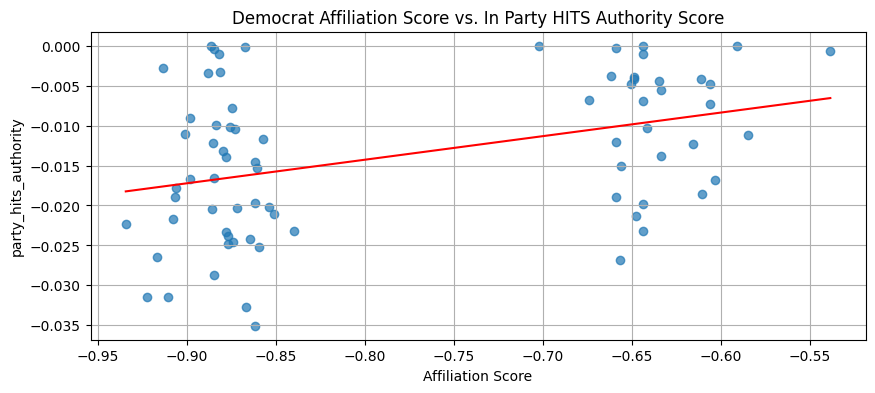

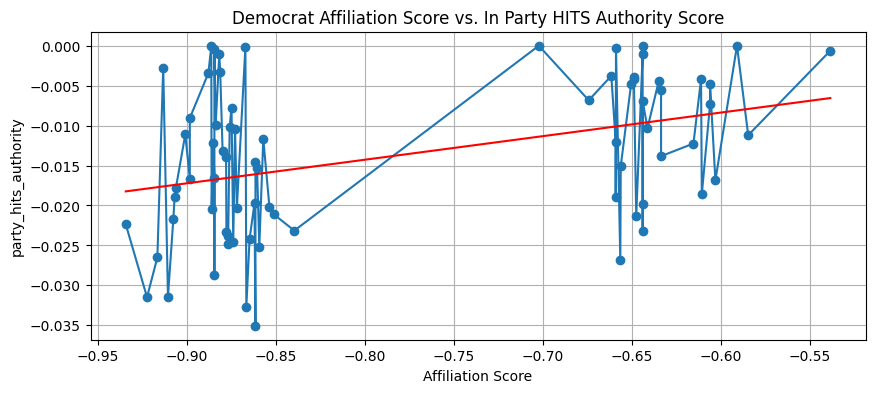

In [2311]:
affiliation_degree_dist("Republican",republican_df, 'party_hits_authority', 'In Party HITS Authority Score')
affiliation_degree_dist("Democrat",democratic_df, 'party_hits_authority', 'In Party HITS Authority Score')

In [2210]:
df_data

,current_twitter_name,party,complete_following,following,affiliation_score,strength,degree_ratio,degree_ratio2,neighbour_degree_ratio,neighbour_degree_ratio2,...,internal_degree,external_degree,total_degree,global_core_number,party_core_number,neighbor_affiliation_purity,sameparty_neighbor_affiliation_purity,authority_score,hub_score,party_hits_authority
1,SpeakerRyan,R,"[DarrellIssa, WaysandMeansGOP, cathymcmorris, ...","[DarrellIssa, WaysandMeansGOP, RepKevinBrady, ...",0.969697,strong,3800,5776,195989.25,1295750.75,...,64,12,52,75,64,0.892336,0.901131,0.002546,0.002546,0.005380
2,SpeakerPelosi,D,"[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...","[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...",-0.885246,strong,-2923,-6241,33706.25,1284347.25,...,57,22,35,77,54,0.822409,-0.791038,-0.003678,-0.003678,-0.012208
3,michelebachmann,R,"[DavidLimbaugh, RedState, Heritage, ScottWalke...","[DavidLimbaugh, RedState, Heritage, ScottWalke...",0.965217,strong,4484,13924,226663.50,1822059.50,...,81,37,44,103,71,0.847569,0.862497,0.005611,0.005611,0.011257
4,dwstweets,D,"[donnabrazile, Eugene_Robinson, JaredEMoskowit...","[donnabrazile, Eugene_Robinson, JaredEMoskowit...",-0.878049,strong,-861,-15129,135335.25,1760760.75,...,62,61,1,102,54,0.820014,-0.787328,-0.005236,-0.005236,-0.013877
5,EricCantor,R,"[EWErickson, foxnewspolitics, SpeakerBoehner, ...","[EWErickson, foxnewspolitics, SpeakerBoehner, ...",0.976000,strong,2235,22201,261090.50,2044815.50,...,86,63,23,103,71,0.830844,0.861771,0.018716,0.018716,0.028633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,stabenow,D,"[SenStabenow, SenGaryPeters, gretchenwhitmer, ...","[SenStabenow, SenGaryPeters, gretchenwhitmer, ...",-0.643939,weak,-4,-4,-2302.00,41474.00,...,2,0,2,2,2,0.877456,-0.877456,-0.000020,-0.000020,-0.000079
179,sen_joemanchin,D,"[SenatorSinema, lisamurkowski, WVGovernor, Sen...","[SenatorSinema, WVGovernor, SenCapito, SenJoni...",-0.584615,weak,1269,-19881,181936.75,1921713.25,...,63,78,-15,103,54,0.828808,-0.792958,-0.005946,-0.005946,-0.011202
180,sendancoats,R,"[AttyAbdul, lisamurkowski, nkellyIN, marybschn...","[AttyAbdul, nkellyIN, marybschneider, camsavag...",0.707692,weak,2829,15129,211159.75,1907619.25,...,76,47,29,103,71,0.831731,0.859382,0.003357,0.003357,0.005271
181,mcconnellpress,R,"[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...","[LeaderMcConnell, KYGOP, SenJohnThune, JamesCo...",0.628788,weak,2079,3969,129921.75,1089857.25,...,50,13,37,63,50,0.801582,0.832977,0.000817,0.000817,0.001512
